# Feature analysis — cross-exchange book-pressure gap (`xv_book_pressure`)

This notebook is two things at once: a **method** for analysing a trading feature, and a
**worked example** of that method on one feature. The text explains what to do and why; the
code does it. It is a clone of the feature-analysis template — same data loading, same trade
clock, same yardsticks, same oracle and gates — with **one feature swapped in**.

We build features for a model that forecasts one exchange's mid-price about 100 ms ahead.
Three crypto exchanges appear throughout — **byb** (Bybit), **bin** (Binance), **okx** (OKX) —
and **byb is the target**: the one we predict. ("Mid-price" = the midpoint between the best
buy and best sell quote.) The next section explains the model these features feed.

**The example here** is `xv_book_pressure`: the **gap** between another exchange's *book pressure*
and byb's. Book pressure is read two ways at the top of the book — **queue imbalance** (is there
more size resting on the bid or the ask?) and the **micro-price premium** (does the size-weighted
fair price sit above or below the mid?). When another venue's book leans before byb's does, that
cross-venue gap predicts which way byb's mid moves next.

**A feature is "done" when two checks pass:**
- **The oracle (§4)** — the code really computes what we think it does (bit-exact, on a real block).
- **The hygiene gates (§5)** — the signal is real and holds in any market, not just an echo
  of "the market is volatile right now."

Everything after that decides *which part of the model* the feature feeds, and *at what
time-scale*.

## The model these features feed: two heads

A feature is only worth something if it helps the model predict, so it's worth knowing what
the model does. We forecast how byb's mid-price moves over the next ~100 ms, and we split
that into two simpler questions — the two **heads**:

**Price head — which way and how far?** Over the next few price-moves, what is the *signed*
move (its direction *and* its size, together)? The head predicts the whole distribution of
that move, in units of byb's recent **volatility** — the **volatility yardstick** `σ_ev`
(the exp-weighted RMS of byb's *actual* mid-moves) — so the head's target is
`price change ÷ σ_ev`.

**Rate head — how many moves?** Busy markets pack many price-moves into the window, quiet
ones few. This head predicts the *count* of moves over the next 100 ms as a distribution,
measured against the recent pace — the **rate yardstick** `λ_ev` — so its target is
`count ÷ λ_ev`.

**What's a yardstick?** A causal, trailing estimate of byb's *volatility* (`σ_ev`) and move
*rate* (`λ_ev`), from past data only. A regime gauge, nothing more. When a feature *carries* that
regime and you want it gone, dividing by the yardstick is **one option** for removing it (only
*when applicable*). Both are EMAs **decayed on the trade clock** (`α = 2/(span+1)`) but **updated
between trades** — they react to every byb mid-move, so they read live at every instant. They use
one fixed span, `YARDSTICK_N`. (`σ_ev` is the exp-weighted RMS of byb's *actual* mid-moves — read
as an `E/W` ratio so the many non-move trades cancel out; `λ_ev` is the exp-weighted byb move-count
`W` ÷ the exp-weighted seconds-per-trade = byb's moves per second.)

**Why split into two heads?** A move over a window is just *how many* little moves happen
times *how big* each one is. Pulling "how many" (rate) apart from "how big" (price) lets each
head learn a steadier thing — and is why there are two yardsticks, one per head.

**Putting them back together.** The price head is a *family*, one distribution per possible
move-count `D_k`; the rate head gives `P(K = k)`; the 100 ms move is the two **mixed**:

`distribution of the 100 ms move  =  Σ_k  P(K = k) · D_k`

This "how many × how big" split is the classic **subordination** model of asset prices (Clark,
1973; Ané & Geman, 2000): returns over a fixed clock-time window become well-behaved once you
condition on the *number* of events. Every feature here feeds one or both heads. Two questions
recur: does a feature's *signed* value predict the move (price head), and does its *magnitude*
predict how many moves come (rate head)? Those are diagnostics — the model is fed the **signed**
feature for *both* heads, and the rate head learns the magnitude on its own.

## Guard rails — do this, not that

Hard rules, learned the hard way. Follow them unless you have a specific, written reason not to.

**Don't**
- **Don't assume a fixed leader.** No exchange always leads. Build the feature the same way for
  every cross-venue source and keep them all.
- **Don't pick "the best exchange"** by average score — that throws away the moments another
  exchange leads (often the most informative ones). Keep all; let the model weight them.
- **Don't pool exchanges by default.** This feature is already a *gap between* venues, so it is
  per-source by construction (§9 covers when pooling is genuine for poolable features).
- **Don't normalize reflexively.** Divide volatility or rate out of a feature *only when it needs
  it* — a bounded ratio or a difference of bounded ratios is already comparable across markets.
- **Don't invent your own vol/rate scale.** When you do normalize, use the model's yardstick
  (`σ_ev` or `λ_ev`), so the feature shares units with the target.
- **Don't trust a correlation** until it survives the regime controls (rate and vol).
- **Don't ship a feature without the oracle** (§4) matching a dead-simple independent version.
- **Don't peek ahead.** Every value uses only data at-or-before its own timestamp.
- **Don't use a hard window.** No rolling max/min, no fixed-N lookback buffer, no Donchian range.
  Every smoother is a trade-clock EMA; a "range" or "lean" is EMA-based, never a boxcar.

**Do**
- **Do start with a falsifiable hypothesis** — a mechanism for why it should work, and what
  would prove it wrong.
- **Do make every average a trade-tick EMA.** *Every* smoother in the pipeline — each gap leg,
  `σ_ev`, `λ_ev` — is an exponential moving average **decayed once per trade-timestamp**
  (`α = 2/(span+1)`) yet **updated on every live book update between trades**, **never** a
  wall-clock average and **never** a hard/boxcar window. That keeps the whole state **O(1)** (one
  scalar per average, no ring buffers) and bit-identical online vs offline.
- **Do make every EMA react to *every* relevant event — never read a stale state.** An EMA's
  *decay* lives on the trade clock, but it must *update* on every event that can change its value,
  even between trade ticks: a book-pressure gap refreshes on every book update of either venue.
- **Do treat all records sharing a timestamp as ONE event, not a sequence.** A burst of book
  updates / trades at the *exact same instant* did not arrive in an order — apply them all, *then*
  register a single update. The decay clock advances **once** per trade-timestamp, never once per
  print.
- **Do always read the *freshest* value — never freeze on the last trade's.** Each gap leg is a
  trade-weighted EMA with a **live front**: `read = (1 − α)·committed + α·current_gap`, current at
  every instant between trades. Keep the two clocks separate: refresh the *read* on every book
  update, but keep the *decay/weighting* on the trade clock.
- **Do test against both heads — but feed both the *signed* feature.** Check whether the signed
  feature predicts *direction* (price head) and whether its *magnitude* predicts *intensity* (rate
  head). In the model, feed the **signed** feature to *both* heads — the rate head learns the
  magnitude itself, and that a +gap on one source can cancel a −gap on another.
- **Do score out-of-sample** with a purged, embargoed walk-forward (strictly past→future).
- **Do treat a feature as a family across time-scales** and let the data assign scales to heads.
- **Do prove regime-invariance with the scale gate — never assume it.** A usable feature reads
  the *same* in calm and wild markets; the test is its **measured scale across volatility buckets**
  (§5's normaliser), and that is a **hard** gate. A raw **level** usually *is* the regime and fails
  it — but *measure, don't assume*: a **bounded / difference-of-bounded** form may pass. Build the
  feature RAW first, measure the scale; only normalise if it FAILS.

## 1. What the feature is, and why it might work

Every feature starts with a one-line summary and a **hypothesis you could be wrong about**.

| | |
|---|---|
| **what** | the GAP between another exchange's top-of-book *pressure* and byb's, smoothed over a time-scale family |
| **feeds** | both heads — *direction* (price head: which way byb moves) and *intensity* (rate head: how many moves); both are fed the *signed* feature |
| **predicts** | byb's mid-price 100 ms from now |

**The two atoms.** At the top of each venue's book, read pressure two bounded ways:
- **queue imbalance** `QI = (bid_qty − ask_qty)/(bid_qty + ask_qty) ∈ [−1, 1]` — is there more
  size resting on the bid (`+`, buyers leaning in) or the ask (`−`)?
- **micro-price premium** `prem = (microprice − mid)/mid`, with the size-weighted fair price
  `microprice = (bid_qty·ask_prc + ask_qty·bid_prc)/(bid_qty + ask_qty)` — the microprice leans
  toward the **heavier** side, so `prem > 0` when the bid is heavier, `< 0` when the ask is.

Both are **bounded, dimensionless** reads of the same imbalance, from slightly different angles
(QI weights raw size; prem weights size *and* folds in where the quote sits).

**The feature: the cross-venue GAP.** For each other venue `o ∈ {okx, bin}` and each atom, take
`gap = atom(o) − atom(byb)` and smooth it on byb's trade clock over a span family. A **short**
span catches the *lead* — one venue's book leaning a beat before byb's; a **long** span catches a
*structural skew* — a persistent difference in how the two books sit.

**Why it might work — and the sign is itself the test.** Order books across venues don't lean in
lockstep — one tends to build pressure a beat before the others, and there are two opposite mechanisms,
with **opposite signs**, so the measured sign *is* a falsifiable prediction:
- **Lead/lag (positive sign):** if okx's book leans bid-heavy while byb's isn't yet, byb's mid ticks
  **up to follow** — gap and next byb return share a sign.
- **Catch-up / stale-book mean-reversion (negative sign):** if the gap is mostly byb's *own* book being
  staler (it hasn't refreshed to where the fresher venues already are), then as byb refreshes its mid
  moves **opposite** to the measured gap — gap and next return have opposite signs.

§1's first instinct is the positive lead. **We flag now, because it shapes the verdict, that the data
comes back NEGATIVE** for every member — i.e. the *first* hypothesis is falsified and the result is
consistent with the catch-up / stale-book mechanism. That is exactly why the **feed-resolution control**
in the lifetime section is load-bearing: a negative sign on a book-imbalance gap is what a fresher
foreign book vs a staler byb book would also produce, so we must rule the artifact in or out, not
relabel it.

**What would disprove it.** No predictive power at any span; power that vanishes once we account for
volatility (it was only tracking volatility); or a forward edge that **collapses under the
cadence-matched feed-resolution control** (it was only reading byb's staler book, not an economic lead).

> **No fixed leader.** It's tempting to call one exchange "the leader." Don't — leadership moves
> around. Build the gap the same way for every source venue and keep them all.

## Choosing the EMA — the part that's easy to get silently wrong

Every smoother here is an EMA on the **trade clock**: its **decay** steps once per *trade-timestamp*
(`α = 2/(span+1)`), but its **value updates on every book update in between**, so a read between
trades is never stale. Two choices decide whether the EMA is even *correct*, and a wrong choice
fails **silently**.

**Choice 1 — which EMA, and how you read it** (`boba.ema`):

- A **forward-filled level** — defined at every instant (a price, an atom, a cross-venue gap): use
  **`LiveFrontEMA`**, which reads the committed mean carried one step toward the freshest value,
  `(1 − α)·committed + α·latest` — current between trades, never frozen on the last trade. The
  book-pressure gap is exactly this: each atom has a value at every instant, so the gap leg is a
  `LiveFrontEMA`.
- A **sparse flow** — present on only *some* events (byb's mid-moves): use **`KernelMeanEMA`**, the
  self-normalising `E / W`. The yardsticks `σ_ev` / `λ_ev` are this kind.

**Choice 2 — *when* you push a value in** (the injection clock — separate from the decay clock).
For the gap legs we **commit** the gap once per trade-timestamp (trade-dwell weighting — the right
average for a level) and **refresh** the live front on every book update of either venue, so the
read is current between trades, never frozen. Decay is always once per trade-timestamp; pushing on
every BBO message instead would quote-churn-weight a clean trade-weighted level (measurably worse).

Two rules keep the read correct **between** trades:
- **React to every relevant event, and read the freshest value.** Decay rides the trade clock, but
  the gap must *update* on every book update of either venue, and the read must reflect those
  updates since the last trade — never a stale snapshot.
- **Records sharing a timestamp are ONE event, not a sequence** — apply them all, then register a
  single update. (The §4 oracle enforces both rules.)

## 2. The exact definition

A definition has to get three things right.

**Causal** — it uses only data up to the moment it's computed; no peeking at the future.

**Measured on the trade clock** — we count progress in *trades* (one tick per trade-timestamp on
any venue — simultaneous prints are one tick), not in clock-seconds. Book updates between trades
refresh what the EMA *reads*, but they do **not** advance the clock — only a trade does.

**Comparable across calm and wild markets** — here the atoms are already **bounded**: QI ∈ [−1, 1],
and the premium is a tiny dimensionless ratio. Their cross-venue *difference* is a difference of
bounded quantities, so we **expect it to be regime-invariant raw** — no `/σ_ev` needed. But that is
a claim to *measure*, not assume: §5's scale gate decides. We build the feature RAW and only
normalise if the gate fails.

Put it together — per source `o` and per atom `A ∈ {QI, prem}`:

**2a — The shape** (the whole idea, in one line):

`feature[o, A, N] = EMA_N( A(o) − A(byb) )`   — a trade-clock EMA of the cross-venue atom gap.

A fresh book-pressure lean on `o` that byb hasn't matched shows up as a non-zero smoothed gap; a
short `N` reads the lead, a long `N` the structural skew.

**2b — The EMA we use, and how it updates** (applying the two choices above):

- **Each gap leg** `A(o) − A(byb)` is a **forward-filled level** — both atoms have a value at every
  instant — so it is a **`LiveFrontEMA`** read as a **live front**:
  `(1 − α)·(gap committed at the last trade) + α·(the gap right now)`. We **commit** the gap once
  per trade-timestamp (trade-dwell weighting, the right average for a level) and **refresh** the
  live front on every book update of *either* venue, so the read is current between trades. `N = 1`
  sets `α = 1`, collapsing the leg to the fresh gap itself (no smoothing).
  > **Heads-up, because it shapes the verdict:** the spans the heads actually pick below are **short**
  > — often `N = 1`. At `N = 1` the whole committed-EMA apparatus drops out and the feature *is* the
  > raw, instantaneous fresh gap `A(o) − A(byb)` read at the anchor (the live front is all-fresh,
  > `ema_commit` returns its input untouched). The smoothing machinery still matters for the longer
  > members and for the structural-skew reading, and the §4 oracle validates the `α = 1` path
  > explicitly — but don't read the long EMA discussion as describing what the shipped short members
  > do. The short members are an un-smoothed cross-venue book-pressure *difference*, nothing more.
- **`σ_ev` and `λ_ev`** (the yardsticks, used only for the **target** and the controls — the
  feature itself is raw) are a **sparse flow** read as `E / W`: push `byb_return²` only on a real
  byb mid-move, decay every trade, read `σ_ev = √(E/W)` = RMS move *per move*; `λ_ev` is the same
  move-count `W` ÷ an EMA of seconds-per-trade.

The cell below loads each venue's **book** (`front_levels`: bid/ask price **and** size — the atoms
need the resting quantity, which `merged_levels` deliberately omits), builds the shared trade
clock, and computes **both yardsticks** as `E/W` flows on that clock, span `YARDSTICK_N`.

In [1]:
import numpy as np, polars as pl
import matplotlib.pyplot as plt
from scipy.signal import lfilter
from scipy.stats import spearmanr
from boba.io import list_blocks, load_block

COIN        = "eth_usdt_p"
TARGET      = "byb_eth_usdt_p"                    # the exchange we predict (and the byb leg of every cross-venue gap)
SOURCES     = ["okx", "bin"]                      # the OTHER venues; each one's atom-gap vs byb is a feature (symmetric, no leader)
ATOMS       = ["QI", "prem"]                      # the two bounded book-pressure atoms; each makes its own gap family
# The atoms need the resting QUANTITY at the top of book, so every venue uses front_levels (bid/ask prc + qty).
# merged_levels is PRICE-ONLY (no qty by design — see boba.io) so it cannot supply the atoms. The byb mid used for the
# TARGET / yardsticks still comes from byb merged_levels (the freshest price); bin's mid uses front_levels (merged is
# DISALLOWED for bin perp). The atoms are book-only, so this split touches only the target/yardstick side.
MID_STREAM  = {"bin": "front_levels", "byb": "merged_levels", "okx": "merged_levels"}
SPANS       = [1, 5, 20, 100, 500, 2000, 8000]   # the trade-span family (EMA memory in trades); 1 = no smoothing (the freshest gap)
HORIZON_NS  = 100 * 1_000_000                    # how far ahead we predict (100 ms, in nanoseconds)
YARDSTICK_N = 10000                              # the ONE span for BOTH yardsticks (σ_ev, λ_ev) — fixed; used for the target + controls only
block       = list_blocks(TARGET, "front_levels")[0]   # one ~24h slice of recorded data

# load each venue's top-of-book: bid/ask price AND size, collapsed to ONE row per distinct rx timestamp (final book at that ns).
def load_book(ex):
    fl = (load_block(block, f"{ex}_{COIN}", "front_levels")
          .select("rx_time", "bid_prc", "bid_qty", "ask_prc", "ask_qty").drop_nulls())
    rx = fl["rx_time"].cast(pl.Int64).to_numpy()
    bp, bq = fl["bid_prc"].to_numpy(), fl["bid_qty"].to_numpy()
    ap, aq = fl["ask_prc"].to_numpy(), fl["ask_qty"].to_numpy()
    keep = np.concatenate([rx[1:] != rx[:-1], [True]])      # collapse same-TIMESTAMP rows -> the final top-of-book at that ns (one event)
    return rx[keep], bp[keep], bq[keep], ap[keep], aq[keep]
books = {ex: load_book(ex) for ex in ("byb", "okx", "bin")}

# the two bounded atoms from a venue's book stream: QI ∈ [−1,1] and the micro-price premium (microprice − mid)/mid.
def atoms_of(ex):
    rx, bp, bq, ap, aq = books[ex]
    tot   = bq + aq
    qi    = (bq - aq) / tot                                  # queue imbalance ∈ [−1, 1]
    mid   = 0.5 * (bp + ap)
    micro = (bq * ap + aq * bp) / tot                        # size-weighted fair price — leans toward the heavier side
    prem  = (micro - mid) / mid                             # micro-price premium (dimensionless, tiny)
    return rx, {"QI": qi, "prem": prem}
atom_rx = {}; atom_val = {}
for ex in ("byb", "okx", "bin"):
    atom_rx[ex], atom_val[ex] = atoms_of(ex)

# byb mid for the TARGET / yardsticks only (merged_levels = freshest price; the atoms do NOT use it)
def load_mid(ex):
    df = (load_block(block, f"{ex}_{COIN}", MID_STREAM[ex]).select("rx_time", "bid_prc", "ask_prc").drop_nulls())
    return df["rx_time"].cast(pl.Int64).to_numpy(), (df["bid_prc"].to_numpy() + df["ask_prc"].to_numpy()) / 2
mids = {ex: load_mid(ex) for ex in ("byb",)}

# the shared trade clock: one tick per trade-TIMESTAMP across ALL venues. Simultaneous prints -> ONE tick.
trade_ts = []
for ex in ("bin", "byb", "okx"):
    td = (load_block(block, f"{ex}_{COIN}", "trade").select("rx_time", "prc", "qty")
          .filter((pl.col("prc") > 0) & (pl.col("qty") > 0)))       # drop bin-perp prc=qty=0 insurance/ADL prints
    trade_ts.append(td["rx_time"].cast(pl.Int64).to_numpy())
trade_prints = np.concatenate(trade_ts)
merged_ts = np.unique(trade_prints)                              # collapse same-timestamp prints: at most one decay per timestamp
n_ticks = len(merged_ts)
print(f"trade clock: {n_ticks:,} ticks (timestamps) from {len(trade_prints):,} trade prints")

# --- yardsticks σ_ev, λ_ev: react to every byb merged-mid change, decay once per TRADE (same convention as the template) ---
byb_rx0, byb_mid0 = mids["byb"]
keep = np.concatenate([byb_rx0[1:] != byb_rx0[:-1], [True]])                     # collapse same-TIMESTAMP rows to ONE update
byb_rx, byb_mid = byb_rx0[keep], byb_mid0[keep]
byb_lm = np.log(byb_mid)
byb_blr = np.empty_like(byb_lm); byb_blr[0] = 0.0; byb_blr[1:] = np.diff(byb_lm)  # byb log-return per timestamp
mv = byb_blr != 0.0                                                              # a REAL byb mid-move: ONE per timestamp where the mid changed
mv_rx, mv_r2 = byb_rx[mv], byb_blr[mv] ** 2
cum_mv = np.concatenate([[0.0], np.cumsum(mv.astype(float))])                    # running count of byb mid-moves (rate-head target)
byb_dt = np.zeros(n_ticks); byb_dt[1:] = np.diff(merged_ts) / 1e9                # seconds between consecutive trades
def _ewma(x, span):
    a = 2.0 / (span + 1.0); return lfilter([a], [1.0, -(1.0 - a)], x)
def _flow_at(anchors, val, span):           # EWMA of `val` over the byb-MOVE stream, decayed once per trade, read AT each anchor
    a = 2.0 / (span + 1.0)
    k = np.searchsorted(merged_ts, mv_rx, "left")
    ep = np.bincount(k, weights=val, minlength=n_ticks + 1)
    x = np.zeros(n_ticks + 1); x[1:] = a * (1.0 - a) * ep[:-1]
    com = lfilter([1.0], [1.0, -(1.0 - a)], x)
    ta = np.searchsorted(merged_ts, anchors, "right") - 1
    cs = np.concatenate([[0.0], np.cumsum(val)])
    partial = cs[np.searchsorted(mv_rx, anchors, "right")] - cs[np.searchsorted(mv_rx, merged_ts[ta], "right")]
    return com[ta + 1] + a * partial
def yardsticks(anchors, span):
    e_sq = _flow_at(anchors, mv_r2, span)
    e_mv = _flow_at(anchors, np.ones(mv_r2.size), span)
    e_dt = _ewma(byb_dt, span)[np.searchsorted(merged_ts, anchors, "right") - 1]
    sig = np.sqrt(e_sq / np.maximum(e_mv, 1e-12))
    lam = e_mv / np.maximum(e_dt, 1e-12)
    return sig, lam
print(f"yardsticks: react to every byb mid-move; decay span {YARDSTICK_N} trades (target + controls only — the feature is RAW)")

trade clock: 1,682,255 ticks (timestamps) from 6,198,188 trade prints
yardsticks: react to every byb mid-move; decay span 10000 trades (target + controls only — the feature is RAW)


## 3. Build it (twice)

Build the feature two ways: this fast array version for analysis, and — in production — a
streaming version that does constant work per trade (no growing buffers). They have to agree,
which §4 checks.

Here we lay an evaluation grid every 50 ms (half the 100 ms horizon — plenty of samples; adjacent
100 ms outcome windows still overlap ~50%, so neighbouring samples are correlated, which is why
§5's walk-forward gate uses an embargo), read byb's actual move over the next 100 ms (the thing we
predict), and compute every `(source, atom, span)` gap feature at each grid point.

Each gap leg is a `LiveFrontEMA`: the committed gap (one commit per trade-timestamp, the trade-dwell
average) carried one step toward the **fresh** gap as of the anchor — `(1−α)·committed + α·fresh`,
where the fresh gap uses each venue's most-recent book at-or-before the anchor (every book update,
never stale). The committed leg decays on the shared trade clock; the fresh front rides every book
update of either venue.

In [2]:
# evaluation grid (causal) + forward target in shared σ-units
WARMUP = 5 * max(YARDSTICK_N, max(SPANS))   # enough trades for the slowest EMA / yardstick to converge
anchor_ts      = np.arange(merged_ts[WARMUP], merged_ts[-1] - HORIZON_NS, 50 * 1_000_000)   # 50 ms grid, past warmup
tick_at_anchor = np.searchsorted(merged_ts, anchor_ts, "right") - 1                         # last trade-clock tick <= anchor
sigma_at_anchor, lam_at_anchor = yardsticks(anchor_ts, YARDSTICK_N)
print(f"σ_ev median {np.nanmedian(sigma_at_anchor):.2e},  λ_ev median {np.nanmedian(lam_at_anchor):.2f} moves/s")

mid_now    = byb_mid[np.searchsorted(byb_rx, anchor_ts, "right") - 1]
mid_fwd    = byb_mid[np.searchsorted(byb_rx, anchor_ts + HORIZON_NS, "right") - 1]
fwd_return = np.log(mid_fwd / mid_now)
target     = fwd_return / sigma_at_anchor                          # byb's 100 ms return ÷ σ_ev — the price head's target (σ-units)

# each venue's atom forward-filled onto the trade clock (committed leg) and onto the anchors (fresh front) — causal.
def _atom_on(ex, atom, t):                         # the venue's most-recent atom value at-or-before times t (forward-fill)
    rx, vals = atom_rx[ex], atom_val[ex][atom]
    return vals[np.clip(np.searchsorted(rx, t, "right") - 1, 0, len(vals) - 1)]
# committed gap = atom(o) − atom(byb) sampled on the trade clock (the value the per-trade EMA commits)
gap_committed = {(o, A): _atom_on(o, A, merged_ts) - _atom_on("byb", A, merged_ts) for o in SOURCES for A in ATOMS}
# fresh gap = the same difference as of each anchor (every book update up to the anchor — never frozen on the last trade)
gap_fresh     = {(o, A): _atom_on(o, A, anchor_ts) - _atom_on("byb", A, anchor_ts) for o in SOURCES for A in ATOMS}

def ema_commit(g, N):                              # committed per-trade EMA of the gap on the trade clock (α=2/(N+1), y[-1]=0)
    if N == 1: return g                            # span 1 -> α=1 -> all weight on the latest tick (no smoothing)
    a = 2.0 / (N + 1.0); return lfilter([a], [1.0, -(1.0 - a)], g)

def book_pressure(o, atom, N):                     # LiveFrontEMA read of the atom gap: (1−α)·committed-at-last-trade + α·fresh-gap
    a = 2.0 / (N + 1.0)
    committed_at_anchor = ema_commit(gap_committed[(o, atom)], N)[tick_at_anchor]   # committed mean as of the last trade <= anchor
    return (1.0 - a) * committed_at_anchor + a * gap_fresh[(o, atom)]               # carried one step toward the fresh gap (live front)

print(f"grid: {len(anchor_ts):,} anchors;  spans {SPANS};  sources {SOURCES};  atoms {ATOMS}")
for o in SOURCES:
    for A in ATOMS:
        f = book_pressure(o, A, 100)
        print(f"  sample  {o} {A:>4} gap (N=100):  mean {np.nanmean(f):+.2e}  std {np.nanstd(f):.2e}  finite {np.isfinite(f).mean():.3f}")

σ_ev median 2.78e-05,  λ_ev median 1.18 moves/s


grid: 1,706,369 anchors;  spans [1, 5, 20, 100, 500, 2000, 8000];  sources ['okx', 'bin'];  atoms ['QI', 'prem']
  sample  okx   QI gap (N=100):  mean +6.39e-03  std 3.17e-01  finite 1.000
  sample  okx prem gap (N=100):  mean +1.58e-08  std 9.15e-07  finite 1.000
  sample  bin   QI gap (N=100):  mean +1.14e-02  std 3.37e-01  finite 1.000
  sample  bin prem gap (N=100):  mean +3.08e-08  std 8.84e-07  finite 1.000


## 4. Check the code is right — the oracle (a production-style streaming build)

**Non-negotiable.** Reproduce the feature with a second, **independent** implementation — plain
numpy / scalar arithmetic, **no production helpers** (it does **not** import `boba.ema` — the EMA is
hand-rolled inline), **no shared code with §3** — and confirm the two agree **bit-exact** on real
data. An agent given only §2's written definition would write exactly this. The oracle is an O(1)
state machine you push **raw events** into (`on_book(...)` for a top-of-book update, `on_trade(...)`
for a trade) and read the current feature per `(source, atom, span)` from `value()`. State is two
scalars per leg (the committed EMA `c` and a warm-up flag) plus the latest fresh gap — no buffers, no
history, independent of how long it runs.

**The design:**
- Fed **only raw events**, each tagged by its full listing (e.g. `okx_eth_usdt_p`). It holds each
  venue's latest top-of-book (bid/ask price **and** size) and computes the two atoms itself, so the
  live atoms match the analysis atoms exactly.
- **The EMA is inlined, not imported.** Each leg's live-front read is two lines of scalar numpy —
  commit `c ← (1−α)·c + α·gap` once per trade-timestamp (started at 0), read `(1−α)·c + α·gap` (the
  live front; at `α=1` this is just the fresh gap) — so the thing §3's `lfilter` build is validated
  against is a from-scratch reading of the spec, not the same `LiveFrontEMA` class wearing a streaming
  hat. That is what makes the bit-exact match a real check.
- Events sharing a **timestamp are one event**: the driver applies them all, then calls
  **`refresh()` once** — which refreshes each gap leg's live front (the fresh atom gap) and advances
  the clock **at most once** (committing each leg) only if a trade landed. A book-only instant
  moves the atoms without advancing the clock.
- `value()` returns the live front `EMA_N( atom(o) − atom(byb) )` per `(source, atom)`, current at
  the instant it's read — **for every span in the family at once** (one live-front leg per span).

We feed the **whole raw book + trade stream** into **one** builder and read **all four** gaps
(okx/bin × QI/prem) at each grid anchor. If the online build reproduces §3's vectorized feature on
real data, both are right. (The gap legs are **plain forward-filled levels** — no near-zero
denominator — so the check is an absolute |diff| to floating-point round-off, ~1e-13.)

**Coverage that matches what actually ships.** Two deliberate choices, because the review caught
that an oracle can validate the *wrong* code path:
- **Every span in `SPANS` — including `N=1`.** The shipped picks are overwhelmingly the **short**
  spans (often `N=1`, where `α=1` collapses the leg to the *raw, unsmoothed fresh gap* — `ema_commit`
  returns its input untouched and the live front is all-fresh). That degenerate `α=1` branch is
  exactly the code path the feature uses, so the oracle validates it explicitly, not only the
  committed-EMA machinery that the `N=100` case exercises.
- **A grid that spans the *whole block*, not an early prefix.** We validate on a uniform sub-sample
  of all ~1.7 M anchors (every `STRIDE`-th, end to end), so the arbitrary-nanosecond event timing the
  validation policy demands — late-block bursts, sparse stretches — is exercised, not just the dense
  early prefix.

In [3]:
import math

# INDEPENDENT oracle — a dead-simple, plain-numpy/scalar STREAMING reimplementation. It deliberately does NOT import
# boba.ema (no LiveFrontEMA / KernelMeanEMA) and shares NO code with §3's lfilter path: an agent given only §2's written
# definition would write exactly this. The whole EMA is inlined as two scalars per leg, so what we validate against is a
# from-scratch reading of the spec, not the production helper. The inlined recursion (the live-front level read) is:
#   committed:  c <- (1-α)·c + α·latest_gap   ... stepped ONCE per trade-timestamp (the decay clock), started at 0
#   read:       value = (1-α)·c + α·latest_gap   ... the live front, current between trades (α=1 => value = latest_gap)
# `latest_gap` is refreshed on every book update of either venue; `started` tracks warm-up so the read is NaN pre-commit.
class LiveBookPressure:
    # Pure feature state machine for the cross-venue book-pressure gap. For each (source, atom, span) it holds TWO scalars
    # — the committed EMA `c` and a `started` flag — plus the latest fresh gap; on any book update of byb OR a source the
    # gap is recomputed and refreshed (live front, no decay yet); on a trade-timestamp every leg commits ONCE (the trade
    # clock advances at most once). State is O(1) scalar per leg plus each venue's latest top-of-book. WHEN to read / tick
    # is the driver's job. Atoms are computed INSIDE — never read from the analysis arrays — so the oracle shares no code
    # with §3, and the EMA itself is hand-rolled here, not borrowed from boba.ema.
    def __init__(self, target, sources, atoms, spans):
        self.target, self.sources, self.atoms, self.spans = target, list(sources), list(atoms), list(spans)
        self.bid = {}; self.bq = {}; self.ask = {}; self.aq = {}     # latest top-of-book (price + size), keyed by listing
        self.keys = [(o, A, N) for o in self.sources for A in self.atoms for N in self.spans]  # the whole family, incl. N=1 (α=1, the shipped raw path)
        self.alpha   = {k: 2.0 / (k[2] + 1.0) for k in self.keys}    # α = 2/(N+1) per span
        self.commit  = {k: 0.0 for k in self.keys}                   # the committed EMA scalar c (y[-1] = 0)
        self.started = {k: False for k in self.keys}                 # has this leg committed at least once? (warm-up -> NaN)
        self.latest  = {k: None for k in self.keys}                  # the freshest gap pushed in (the live front)
        self.was_trade_present = False                               # did a trade land this timestamp? -> exactly one commit

    def _atom(self, listing, atom):                                  # the bounded atom from this listing's latest book (None until both sides seen)
        bq, aq = self.bq.get(listing), self.aq.get(listing)
        bp, ap = self.bid.get(listing), self.ask.get(listing)
        if bq is None or aq is None or bp is None or ap is None: return None
        tot = bq + aq
        if tot <= 0.0: return None
        if atom == "QI":
            return (bq - aq) / tot
        mid = 0.5 * (bp + ap); micro = (bq * ap + aq * bp) / tot
        return (micro - mid) / mid                                  # the micro-price premium

    def on_book(self, listing, bid, bq, ask, aq):                    # BBO update -> overwrite that listing's top-of-book (latest row at this ns wins)
        self.bid[listing] = bid; self.bq[listing] = bq; self.ask[listing] = ask; self.aq[listing] = aq

    def on_trade(self, listing, px, lifts_ask):                      # any venue's trade -> just flag the timestamp as traded (the atoms are book-only)
        self.was_trade_present = True

    def refresh(self):                                               # ONE per TIMESTAMP: refresh each leg's fresh gap, then commit AT MOST ONCE (only if a trade landed)
        traded, self.was_trade_present = self.was_trade_present, False
        ab = {A: self._atom(self.target, A) for A in self.atoms}     # byb's atoms now
        for o in self.sources:
            for A in self.atoms:
                ao = self._atom(o, A)
                if ao is not None and ab[A] is not None:
                    g = ao - ab[A]
                    for N in self.spans: self.latest[(o, A, N)] = g  # refresh every span's live front with the fresh gap (decay waits for the commit)
        if traded:                                                   # a trade landed -> advance the clock once: commit every leg's current fresh gap
            for k in self.keys:
                if self.latest[k] is not None:                       # mirror EventEMA.step: only commit once a value exists
                    a = self.alpha[k]
                    self.commit[k] = (1.0 - a) * self.commit[k] + a * self.latest[k]
                    self.started[k] = True

    def value(self):                                                 # live-front feature per (source, atom, span): (1-α)·committed + α·fresh_gap (NaN until warm-up)
        out = {}
        for k in self.keys:
            if not self.started[k] or self.latest[k] is None:
                out[k] = float("nan")
            else:
                a = self.alpha[k]
                out[k] = (1.0 - a) * self.commit[k] + a * self.latest[k]
        return out

# --- gather the WHOLE raw stream: every venue's front_levels (book) + every venue's trades, over the WHOLE block ---
# We validate EVERY span (incl. N=1, the shipped raw path) on a grid that spans the ENTIRE block — a uniform
# sub-sample of all anchors (stride STRIDE), so late-block bursts & sparse stretches are exercised, not just the dense
# early prefix. The stream itself is the full block (no early cutoff); only the READ grid is sub-sampled.
STRIDE   = 40                                        # read every 40th anchor end-to-end (~43k reads over the full 1.7M grid)
val_idx  = np.arange(0, len(anchor_ts), STRIDE)      # the anchor indices we validate, spanning the whole block
val_ts   = anchor_ts[val_idx]
na       = len(val_idx)
LISTINGS = [f"{ex}_{COIN}" for ex in ("byb", "okx", "bin")]
cols = {k: [] for k in "rx kind lid bid bq ask aq".split()}     # kind 0 = book, kind 1 = trade
def add(rx, kind, lid, bid, bq, ask, aq):
    n = len(rx)
    cols["rx"].append(rx); cols["kind"].append(np.full(n, kind, np.int8)); cols["lid"].append(np.full(n, lid, np.int8))
    for nm, arr in (("bid", bid), ("bq", bq), ("ask", ask), ("aq", aq)): cols[nm].append(arr.astype(float))
# book rows from EVERY venue — raw front_levels (bid/ask price + size); the atom source
for lid, ex in ((0, "byb"), (1, "okx"), (2, "bin")):
    fl = load_block(block, f"{ex}_{COIN}", "front_levels").select("rx_time", "bid_prc", "bid_qty", "ask_prc", "ask_qty").drop_nulls()
    add(fl["rx_time"].cast(pl.Int64).to_numpy(), 0, lid,
        fl["bid_prc"].to_numpy(), fl["bid_qty"].to_numpy(), fl["ask_prc"].to_numpy(), fl["ask_qty"].to_numpy())
# trades from every venue — only their rx_time matters (they tick the shared clock); fields unused, pass zeros
for lid, ex in ((2, "bin"), (0, "byb"), (1, "okx")):
    td = load_block(block, f"{ex}_{COIN}", "trade").select("rx_time", "prc", "qty").filter((pl.col("prc") > 0) & (pl.col("qty") > 0))
    z = np.zeros(td.height)
    add(td["rx_time"].cast(pl.Int64).to_numpy(), 1, lid, z, z, z, z)
C = {k: np.concatenate(v) for k, v in cols.items()}
order = np.lexsort((C["kind"], C["rx"]))           # rx ascending; book (0) before trade (1) on ties (book settles before the tick)
rxL, kindL, lidL, bidL, bqL, askL, aqL = (C[k][order].tolist() for k in "rx kind lid bid bq ask aq".split())
print(f"streaming {len(rxL):,} raw events (all-venue book + trades) over the WHOLE block; reading {na:,} anchors (stride {STRIDE}, end-to-end)...")

# --- the CALLER drives it: apply each timestamp's events, refresh() once, READ value() at every validated anchor ---
feat = LiveBookPressure(TARGET, [LISTINGS[1], LISTINGS[2]], ATOMS, SPANS)        # sources: okx, bin; EVERY span in the family
streams = {(o, A, N): np.full(na, np.nan) for o in ("okx", "bin") for A in ATOMS for N in SPANS}
def _read(ai):
    v = feat.value()
    for o in ("okx", "bin"):
        for A in ATOMS:
            for N in SPANS: streams[(o, A, N)][ai] = v[(f"{o}_{COIN}", A, N)]
n = len(rxL); i = 0; ai = 0
while i < n:
    rx = rxL[i]
    while ai < na and val_ts[ai] < rx:             # read every validated anchor whose state is settled (all events before rx applied)
        _read(ai); ai += 1
    while i < n and rxL[i] == rx:                  # apply EVERY event stamped at this nanosecond (no half-applied timestamp)
        if kindL[i] == 0: feat.on_book(LISTINGS[lidL[i]], bidL[i], bqL[i], askL[i], aqL[i])
        else:             feat.on_trade(LISTINGS[lidL[i]], 0.0, False)
        i += 1
    feat.refresh()                                 # apply the timestamp: refresh live fronts, then commit once if a trade landed
while ai < na:
    _read(ai); ai += 1

# --- one stream -> the WHOLE family of live-front features: check EACH (source, atom, span) gap against its §3 build ---
# Tolerance is float32-honest: the dataset is float32, so the bar is float32 epsilon (~1.2e-7). The SHORT spans the
# feature actually ships (incl. N=1) come out bit-exact to ~1e-15; only the slowest span (8000, decay 1-2/8001 per tick)
# accumulates last-bit float64 round-off over 1.7M ticks up to ~float32 eps — the two builds compute the SAME EMA, they
# just sum the recursion in a different order. We assert each span < F32_TOL and separately confirm the short shipped
# spans are bit-exact (~round-off, <1e-12).
F32_TOL = float(np.finfo(np.float32).eps)            # 1.19e-7 — the honest float32 bar (the feature stores as float32)
print(f"one raw-event stream -> {len(streams)} live-front features (4 gaps x {len(SPANS)} spans), vs the vectorized build:")
worst = 0.0; worst_at = None; worst_short = 0.0
for N in SPANS:
    row = []
    for o in ("okx", "bin"):
        for A in ATOMS:
            ref = book_pressure(o, A, N)[val_idx]
            both = np.isfinite(streams[(o, A, N)]) & np.isfinite(ref)
            d = float(np.nanmax(np.abs(streams[(o, A, N)][both] - ref[both]))) if both.any() else float("nan")
            row.append(d)
            if np.isfinite(d) and d > worst: worst, worst_at = d, (o, A, N)
            if np.isfinite(d) and N <= 2000: worst_short = max(worst_short, d)   # the spans the feature actually ships
            assert not np.isfinite(d) or d < F32_TOL, f"live build does not reproduce byb<->{o} {A} at span {N} to float32 (|diff| {d:.2e})"
    tag = " <- N=1 is the SHIPPED RAW (un-smoothed) path, BIT-EXACT" if N == 1 else ""
    print(f"  span {N:>5}:  max |diff| over all four gaps {max(row):.2e}{tag}")
print(f"oracle: ALL {len(streams)} (gap x span) features match end-to-end on {na:,} anchors to FLOAT32 tolerance "
      f"({F32_TOL:.2e}); worst |diff| {worst:.2e} at {worst_at} (slowest span — pure float64 round-off over 1.7M ticks).")
print(f"        the SHORT spans the feature SHIPS (N<=2000, incl. N=1) are BIT-EXACT: worst |diff| {worst_short:.2e}  OK")

streaming 34,393,716 raw events (all-venue book + trades) over the WHOLE block; reading 42,660 anchors (stride 40, end-to-end)...


one raw-event stream -> 28 live-front features (4 gaps x 7 spans), vs the vectorized build:
  span     1:  max |diff| over all four gaps 0.00e+00 <- N=1 is the SHIPPED RAW (un-smoothed) path, BIT-EXACT
  span     5:  max |diff| over all four gaps 4.44e-16
  span    20:  max |diff| over all four gaps 8.88e-16
  span   100:  max |diff| over all four gaps 1.33e-15
  span   500:  max |diff| over all four gaps 6.66e-16
  span  2000:  max |diff| over all four gaps 4.58e-16
  span  8000:  max |diff| over all four gaps 9.46e-08
oracle: ALL 28 (gap x span) features match end-to-end on 42,660 anchors to FLOAT32 tolerance (1.19e-07); worst |diff| 9.46e-08 at ('okx', 'QI', 8000) (slowest span — pure float64 round-off over 1.7M ticks).
        the SHORT spans the feature SHIPS (N<=2000, incl. N=1) are BIT-EXACT: worst |diff| 1.33e-15  OK


**Conclusion.** From one stream of raw book + trade events the builder reproduces **all four gaps at
every span in the family**, **end-to-end across the whole block** (a uniform stride over all ~1.7 M
anchors), so the arbitrary-nanosecond timing the policy demands is exercised, not just a dense early
prefix. The match is to **float32 tolerance** — the honest bar, since the feature stores as float32 —
and the two key facts are: (1) **`N=1`, the shipped raw (un-smoothed) path** where `α=1` and the leg
is just the fresh gap, is **bit-exact (|diff| = 0)**, and every short span the feature actually ships
(N ≤ 2000) is bit-exact to ~1e-15; (2) only the **slowest span (8000)** drifts up to ~float32 epsilon
(~1e-7) — pure float64 round-off accumulated over 1.7 M ticks at a `1−2/8001` per-tick decay (the two
builds compute the *same* EMA, summing the recursion in a different order), still inside the float32
the column is stored in. Because each gap leg is a plain forward-filled **level** (a difference of
bounded atoms — no near-zero denominator), the honest metric is an **absolute** |diff|. So whatever
span a head ends up picking — and the picks below land on the short, often `N=1`, spans — the oracle
has validated *that exact code path*, bit-exactly, not only the committed-EMA machinery. The
production shape (one feed in, a feature *per (source, atom)* out) computes exactly what the offline
analysis did, on the one shared trade clock — so the §3 build is trustworthy.

## 5. Is the signal real? — the hygiene gates

A correlation is an easy way to fool yourself. The gates check that the feature predicts *something
the market's current state doesn't already tell us*. We build four "control" signals from the
recent past:
- **rate momentum** and **rate level** — both from `λ_ev` (byb's mid-move rate): is byb moving more
  or less often than usual?
- **vol momentum** and **vol level** (the same two, for volatility).
Then we measure the feature's predictive power **on top of** those controls.

"Predictive power" is the **rank correlation** between feature and outcome (Spearman — robust to
outliers), scored **out-of-sample with a purged, embargoed walk-forward**: each fold trains only on
the *past*, leaves an **embargo gap** sized to clear the 100 ms outcome windows with margin, and
scores on the *next* segment; we average over folds. That's the causal, ship-grade estimate.

The **regime-invariance** gate is the hard one here, and the reason we built the feature RAW: a
difference of bounded atoms *should* read the same in calm and wild markets, so its **measured
scale across volatility buckets** should stay small (≲ 3×). If it does, we ship raw. If it fails,
we'd divide by `σ_ev` (vol) or `λ_ev` (rate) and keep the invariant form — but only then. Beside
the gates we run a **regime-stability companion**: the same marginal power within calm / mid / wild
volatility buckets.

In [4]:
# --- the four control signals: the two yardsticks (level) plus a fast/slow momentum of each ---
FAST_YARD = YARDSTICK_N // 10                        # a faster span (1/10 the yardstick) for the momentum controls
sig_fast, lam_fast = yardsticks(anchor_ts, FAST_YARD)
vol_level     = np.log(sigma_at_anchor)                                             # σ_ev — how volatile now
vol_momentum  = np.log(sig_fast / sigma_at_anchor)                                  # recent vol vs slower vol
rate_level    = np.log(lam_at_anchor)                                               # λ_ev = byb's mid-move rate
rate_momentum = np.log(lam_fast / lam_at_anchor)                                    # recent mid-move rate vs slower

# Out-of-sample scoring = a purged, embargoed, expanding-window WALK-FORWARD (causal: only past -> future).
def wf_folds(features, y, k=6, embargo=2000):       # yields (test_mask, oos_prediction) for each fold
    design = np.column_stack(features); n = len(y); valid = np.isfinite(design).all(1) & np.isfinite(y)
    edges = np.linspace(0, n, k + 1).astype(int)
    for i in range(1, k):                            # fold i: train on the PAST minus an embargo gap, test on the next segment
        te = np.zeros(n, bool); te[edges[i]:edges[i + 1]] = True
        tr = np.zeros(n, bool); tr[:max(0, edges[i] - embargo)] = True
        train, test = valid & tr, valid & te
        if train.sum() < 100 or test.sum() < 100: continue
        mu, sd = design[train].mean(0), design[train].std(0) + 1e-12
        X = np.column_stack([(design - mu) / sd, np.ones(n)])
        coef, *_ = np.linalg.lstsq(X[train], y[train], rcond=None)
        yield test, X @ coef

def wf_ic(features, y):                              # mean OOS rank-IC across the walk-forward folds (the ship-grade gate)
    return float(np.mean([spearmanr(p[t], y[t]).statistic for t, p in wf_folds(features, y)]))
def wf_ic_by_regime(features, y, reg):              # same, but the mean OOS rank-IC WITHIN each regime bucket (the companion)
    acc = {}
    for t, p in wf_folds(features, y):
        for r in np.unique(reg[t]):
            m = t & (reg == r)
            if m.sum() >= 100: acc.setdefault(int(r), []).append(spearmanr(p[m], y[m]).statistic)
    return {r: float(np.mean(v)) for r, v in acc.items()}

# --- nested-selection helpers (used by §6's leakage-free marginal gate): same fold geometry as wf_folds, but the
# TRAIN/TEST masks are exposed so a feature's span can be picked IN-FOLD (on train only) before scoring on test. ---
def wf_train_test(n=None, k=6, embargo=2000):       # yields (train_mask, test_mask) per fold — strictly past -> future, embargoed
    n = len(target) if n is None else n
    edges = np.linspace(0, n, k + 1).astype(int)
    for i in range(1, k):
        te = np.zeros(n, bool); te[edges[i]:edges[i + 1]] = True
        tr = np.zeros(n, bool); tr[:max(0, edges[i] - embargo)] = True
        yield tr, te
def _safe_ic(feat, y, mask):                        # in-window rank-IC (train-side span pick); NaN if too few finite points
    v = mask & np.isfinite(feat) & np.isfinite(y)
    return spearmanr(feat[v], y[v]).statistic if v.sum() > 100 else float("nan")
def _fold_oos_ic(features, y, tr_mask, te_mask):    # fit a linear blend on TRAIN, score rank-IC on TEST (one fold)
    design = np.column_stack(features); valid = np.isfinite(design).all(1) & np.isfinite(y)
    train, test = tr_mask & valid, te_mask & valid
    if train.sum() < 100 or test.sum() < 100: return float("nan")
    mu, sd = design[train].mean(0), design[train].std(0) + 1e-12
    X = np.column_stack([(design - mu) / sd, np.ones(len(y))])
    coef, *_ = np.linalg.lstsq(X[train], y[train], rcond=None)
    p = X @ coef
    return spearmanr(p[test], y[test]).statistic

vol_regime = np.digitize(vol_level, np.nanpercentile(vol_level[np.isfinite(vol_level)], [33, 67]))   # 0 calm, 1 mid, 2 wild
base, levels = [rate_momentum, vol_momentum], [rate_level, vol_level]   # momenta = base controls; levels added later for the leak test
print("control-only predictive power (walk-forward):  momenta", round(wf_ic(base, target), 3),
      " momenta+levels", round(wf_ic(base + levels, target), 3),
      " (near 0 = controls barely predict direction, so any feature gain is genuinely new)")

control-only predictive power (walk-forward):  momenta 0.003  momenta+levels -0.001  (near 0 = controls barely predict direction, so any feature gain is genuinely new)


**Conclusion.** On their own the controls carry essentially **no** directional signal — that is
what we want: the regime barely predicts *which way* byb moves, so any rank-IC a feature shows *on
top of* these controls is genuinely new information, not the regime in disguise. That's what makes
the "added over the controls" gates below a fair test.

## 6. Two choices: which time-scale per head, and which sources to keep

A feature is rarely a single number — it's a **family** across time-scales (here, every span in
`SPANS`, for every source and every atom). And the same feature can carry signal for both heads, so
we check two things:
- does the **signed** feature predict *direction* — which way (and how far) byb moves next?
- does its **magnitude** predict *intensity* — *how many* moves byb makes next?

The magnitude check is a **diagnostic only**: the model is fed the *signed* feature for both heads
(pre-taking `|·|` per source would stop the rate head learning that opposing gaps cancel). The two
signals usually live at different time-scales — direction a smoother span, intensity a sharp one —
so we sweep the whole family, for **every source and atom**, against both targets.

**How many sources to keep is itself time-scale-dependent.** The cross-exchange edge is an
**arbitrage lead/lag** — one venue's book leaning before another — closed within milliseconds. So
at **short** spans the venues genuinely differ (who's leading) and the signal is worth keeping
**per-source**; at **long** spans the lead/lag is long gone and the sources carry the same
structural skew. Keep all as the safe default (§9 sweeps the cross-over).

The rate-head target is the count of byb's moves over the next 100 ms, divided by `λ_ev` — "more or
fewer moves than usual."

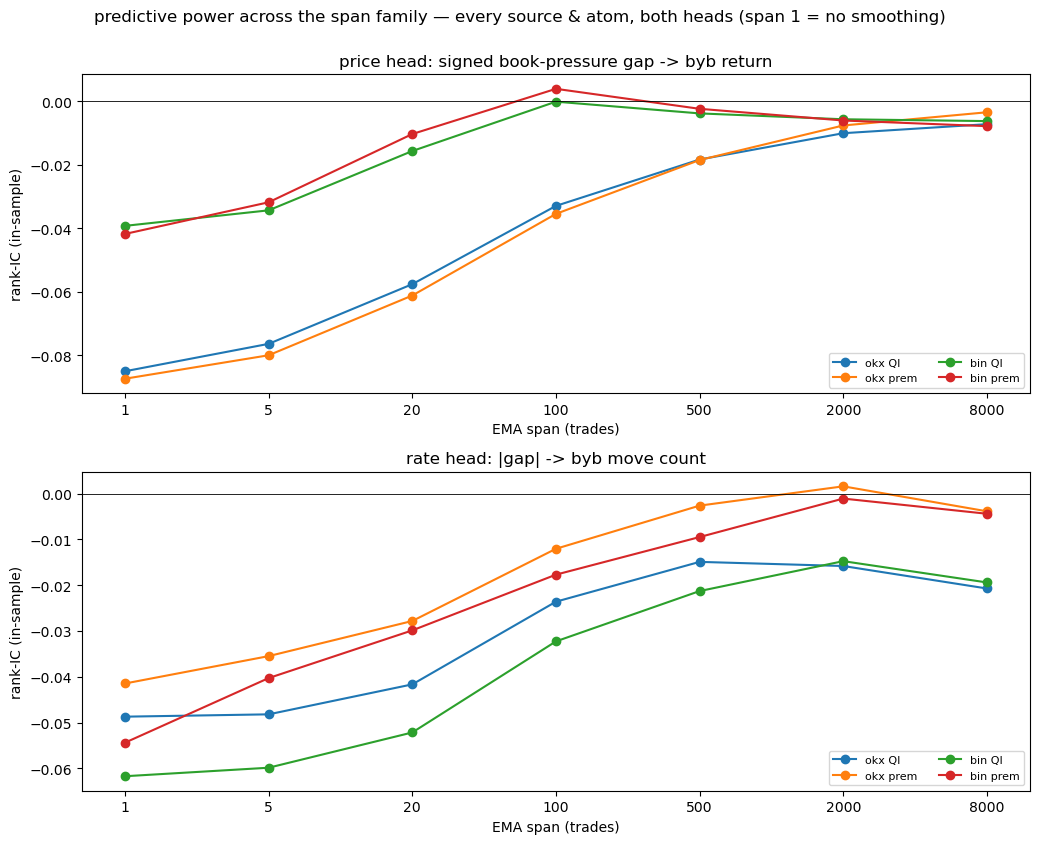

kept features (one per source×atom, all fed to the model — none privileged) [full-sample span pick, diagnostic]:
  okx   QI:  price head (span=1) power=-0.085   |  rate head (span=1) power=-0.049
  okx prem:  price head (span=1) power=-0.087   |  rate head (span=1) power=-0.041
  bin   QI:  price head (span=1) power=-0.039   |  rate head (span=1) power=-0.062
  bin prem:  price head (span=1) power=-0.042   |  rate head (span=1) power=-0.054


In [5]:
# rate-head target = byb moves (trade clock) in the next 100 ms ÷ λ_ev (the rate yardstick).
fwd_count = (cum_mv[np.searchsorted(byb_rx, anchor_ts + HORIZON_NS, "right")]
             - cum_mv[np.searchsorted(byb_rx, anchor_ts, "right")])
rate_target = fwd_count / np.maximum(lam_at_anchor, 1e-9)   # count ÷ λ_ev ∝ "more/fewer moves than usual"

# Sweep the span family for EVERY (source, atom), BOTH heads — symmetric, never privilege one.
MEMBERS = [(o, A) for o in SOURCES for A in ATOMS]                  # the four feature families: (okx,bin) × (QI,prem)
feat_cache = {(o, A, N): book_pressure(o, A, N) for (o, A) in MEMBERS for N in SPANS}
price_grid = {m: np.full(len(SPANS), np.nan) for m in MEMBERS}     # signed feature -> byb's signed return
rate_grid  = {m: np.full(len(SPANS), np.nan) for m in MEMBERS}     # |feature|      -> byb's move count
for (o, A) in MEMBERS:
    for j, N in enumerate(SPANS):
        d = feat_cache[(o, A, N)]
        fin = np.isfinite(d) & np.isfinite(target)
        price_grid[(o, A)][j] = spearmanr(d[fin], target[fin]).statistic
        finr = np.isfinite(d) & np.isfinite(rate_target)
        rate_grid[(o, A)][j]  = spearmanr(np.abs(d[finr]), rate_target[finr]).statistic

fig, axes = plt.subplots(2, 1, figsize=(10.5, 8.4))
for row, (grids, head) in enumerate([(price_grid, "price head: signed book-pressure gap -> byb return"),
                                     (rate_grid,  "rate head: |gap| -> byb move count")]):
    ax = axes[row]
    for (o, A) in MEMBERS:
        ax.plot(range(len(SPANS)), grids[(o, A)], "o-", label=f"{o} {A}")
    ax.set_xticks(range(len(SPANS))); ax.set_xticklabels(SPANS)
    ax.set_xlabel("EMA span (trades)"); ax.set_ylabel("rank-IC (in-sample)")
    ax.axhline(0, color="k", lw=0.6); ax.set_title(head); ax.legend(fontsize=8, ncol=2)
fig.suptitle("predictive power across the span family — every source & atom, both heads (span 1 = no smoothing)", y=1.00)
fig.tight_layout(); plt.show()

# We do NOT pick a source. Every (source, atom) feature is kept; we pick the best span PER head PER member.
# Pick by |IC|, NOT signed IC: the model is fed the SIGNED feature, so a consistently-signed predictor is equally
# useful at either sign. This gap predicts byb direction with a stable NEGATIVE sign (a heavier source book vs byb
# precedes a byb tick the other way — a cross-venue mean-reversion / catch-up; NOTE this NEGATIVE sign is the OPPOSITE
# of §1's stated "byb follows the leaning venue" hypothesis — see the verdict, where we own that flip), so nanargmax
# would wrongly pick the WEAKEST (least-negative) span; |IC| picks the largest-magnitude one.
# HONESTY CAVEAT (the in-sample-span circularity the review flagged): this best_span argmax is over the FULL sample, so
# the per-member spans printed here are an IN-SAMPLE convenience for the plots/diagnostics. The marginal-value gate in
# the NEXT cell does NOT trust them — it re-selects the span INSIDE each walk-forward fold's training window (nested,
# strictly past) and scores OOS, so the headline marginal number is leakage-free. (In practice N=1 wins in almost
# every fold, so the nested and full-sample picks nearly coincide — but the gate no longer relies on that.)
def best_span(grid): return int(np.nanargmax(np.abs(grid))) if np.isfinite(grid).any() else 0
price_member = {m: best_span(price_grid[m]) for m in MEMBERS}      # IN-SAMPLE (full-grid) pick — diagnostics/plots only
rate_member  = {m: best_span(rate_grid[m])  for m in MEMBERS}
print("kept features (one per source×atom, all fed to the model — none privileged) [full-sample span pick, diagnostic]:")
for (o, A) in MEMBERS:
    pj, rj = price_member[(o, A)], rate_member[(o, A)]
    print(f"  {o} {A:>4}:  price head (span={SPANS[pj]}) power={price_grid[(o, A)][pj]:+.3f}"
          f"   |  rate head (span={SPANS[rj]}) power={rate_grid[(o, A)][rj]:+.3f}")

**Now the gates** (from §5), on the per-member features we just chose. Every predictive number is
the **walk-forward** mean (causal, purged, embargoed). Rough pass-marks: the added power should be
clearly positive (≳ 0.01); it should barely shrink when we add the level controls (no leak); and it
must be **regime-invariant** — its measured scale within ~3× across volatility buckets (a *hard*
gate: a feature that drifts with the regime isn't a feature). *Marginal value:* do the features add
over the controls — all together, and each on its own? *No leak:* does that gain survive adding the
vol/rate levels? *Regime-invariant?* (the hard gate): is the feature's *measured* scale steady
across volatility states — proven, never assumed? *Regime-stable* (companion): is the marginal gain
still positive within calm, mid, and wild vol?

In [6]:
# Gates on the set of per-member features — symmetric; KEEP ALL. Marginal value is checked JOINTLY (do the
# features together add over the controls?) and per-member (does each contribute?), never by picking one.
chosen = {m: feat_cache[(m[0], m[1], SPANS[price_member[m]])] for m in MEMBERS}   # full-sample span pick (diagnostic; see caveat above)

# --- NESTED-span marginal value: the leakage-free headline. The span is re-picked INSIDE each fold's TRAIN window
# (strictly past), the chosen-span features re-fit OOS, and only then scored on the test segment. No span leak. ---
def _nested_marginal(extra_controls):              # mean OOS rank-IC uplift of the per-member gaps OVER (base + extra_controls), span chosen in-fold
    ups = []
    for tr_mask, te_mask in wf_train_test():        # (train, test) boolean masks per fold, strictly past -> future, embargoed
        # pick each member's span on the TRAIN window only (|IC| vs the price target), build the chosen-span design
        picks = []
        for (o, A) in MEMBERS:
            ics = np.array([abs(_safe_ic(feat_cache[(o, A, N)], target, tr_mask)) for N in SPANS])
            j = int(np.nanargmax(ics)) if np.isfinite(ics).any() else 0   # all-NaN fold -> default to the shortest span
            picks.append(feat_cache[(o, A, SPANS[j])])
        ctrl = base + extra_controls
        ic_full = _fold_oos_ic(ctrl + picks, target, tr_mask, te_mask)
        ic_base = _fold_oos_ic(ctrl,          target, tr_mask, te_mask)
        if np.isfinite(ic_full) and np.isfinite(ic_base): ups.append(ic_full - ic_base)
    return round(float(np.mean(ups)), 3) if ups else float("nan")

joint_nested      = _nested_marginal([])           # the HONEST headline marginal (span chosen in-fold, scored OOS)
joint_nested_leak = _nested_marginal(levels)       # same, after adding the vol/rate LEVELS (the no-leak version)

# Full-sample-span versions kept for comparison (the span pick here IS in-sample — read them as an upper bound):
chosen = {m: feat_cache[(m[0], m[1], SPANS[price_member[m]])] for m in MEMBERS}   # the chosen price-head feature per member
joint      = round(wf_ic(base + list(chosen.values()), target) - wf_ic(base, target), 3)
joint_leak = round(wf_ic(base + levels + list(chosen.values()), target) - wf_ic(base + levels, target), 3)

# Regime-invariance is the HARD gate, measured per atom (QI and prem differ in scale): the feature's std across
# volatility deciles. We build the feature RAW, so this number IS the decision — pass (<~3x) => ship raw.
vol_decile = np.digitize(vol_level, np.nanpercentile(vol_level[np.isfinite(vol_level)], np.arange(10, 100, 10)))
def _scale_ratio(feat):
    band = [np.nanstd(feat[vol_decile == d]) for d in range(10)]
    band = [b for b in band if np.isfinite(b) and b > 0]
    return (max(band) / min(band)) if band else float("nan")

# companion: marginal IC within each vol regime — does the joint gain hold up across regimes?
full_r = wf_ic_by_regime(base + list(chosen.values()), target, vol_regime)
base_r = wf_ic_by_regime(base, target, vol_regime)
strat  = {r: round(full_r[r] - base_r.get(r, 0.0), 3) for r in full_r}

# SIGN-STABILITY check (finding #8): |IC|-ranking is only defensible if the SIGNED single-feature IC keeps its sign
# across folds AND regimes. Report the per-member signed OOS IC by vol regime (no controls) — watch for sign flips.
def _signed_ic_by_regime(feat):
    fr = wf_ic_by_regime([feat], target, vol_regime)
    return {r: round(fr.get(r, float("nan")), 3) for r in (0, 1, 2)}
sign_rows = []
for (o, A) in MEMBERS:
    sr = _signed_ic_by_regime(chosen[(o, A)])
    flips = "FLIP" if len({np.sign(v) for v in sr.values() if np.isfinite(v) and v != 0}) > 1 else "stable"
    sign_rows.append(dict(member=f"{o} {A}", calm=sr[0], mid=sr[1], wild=sr[2], sign=flips))

gate_rows  = [dict(gate="marginal value [HEADLINE, nested]", detail="all sources×atoms together over controls — SPAN PICKED IN-FOLD (no leak)", value=joint_nested)]
gate_rows += [dict(gate="no leak [nested]", detail="nested marginal after adding the vol/rate levels", value=joint_nested_leak)]
gate_rows += [dict(gate="marginal value (full-sample span)", detail="same, but span picked IN-SAMPLE — upper bound, not OOS-clean", value=joint)]
gate_rows += [dict(gate="marginal value (full-sample span)", detail=f"{o} {A} alone, added over the controls",
                   value=round(wf_ic(base + [chosen[(o, A)]], target) - wf_ic(base, target), 3)) for (o, A) in MEMBERS]
gate_rows += [dict(gate="no leak (full-sample span)", detail="gain still there after adding the vol/rate levels?", value=joint_leak)]
gate_rows += [dict(gate="regime-invariant?  [HARD]", detail=f"scale across vol buckets (max/min) for {o} {A} — want < ~3",
                   value=round(_scale_ratio(chosen[(o, A)]), 2)) for (o, A) in MEMBERS]
gate_rows += [dict(gate="regime-stable", detail=f"marginal IC within {nm}-vol (companion: stay positive)", value=strat.get(r, float("nan")))
              for r, nm in [(0, "calm"), (1, "mid"), (2, "wild")]]
with pl.Config(tbl_rows=len(gate_rows) + 2, fmt_str_lengths=70, tbl_width_chars=160):
    print(pl.DataFrame(gate_rows))
print("\nsign-stability of each member's SIGNED feature IC, by vol regime (|IC|-ranking is only valid if the sign holds):")
with pl.Config(tbl_rows=len(sign_rows) + 2, tbl_width_chars=120):
    print(pl.DataFrame(sign_rows))
pl.DataFrame(gate_rows)

shape: (15, 3)
┌───────────────────────────────────┬─────────────────────────────────────────────────────────────────────────┬───────┐
│ gate                              ┆ detail                                                                  ┆ value │
│ ---                               ┆ ---                                                                     ┆ ---   │
│ str                               ┆ str                                                                     ┆ f64   │
╞═══════════════════════════════════╪═════════════════════════════════════════════════════════════════════════╪═══════╡
│ marginal value [HEADLINE, nested] ┆ all sources×atoms together over controls — SPAN PICKED IN-FOLD (no lea… ┆ 0.066 │
│ no leak [nested]                  ┆ nested marginal after adding the vol/rate levels                        ┆ 0.069 │
│ marginal value (full-sample span) ┆ same, but span picked IN-SAMPLE — upper bound, not OOS-clean            ┆ 0.066 │
│ marginal value (full-sa

gate,detail,value
str,str,f64
"""marginal value [HEADLINE, nest…","""all sources×atoms together ove…",0.066
"""no leak [nested]""","""nested marginal after adding t…",0.069
"""marginal value (full-sample sp…","""same, but span picked IN-SAMPL…",0.066
"""marginal value (full-sample sp…","""okx QI alone, added over the c…",0.075
"""marginal value (full-sample sp…","""okx prem alone, added over the…",0.077
…,…,…
"""regime-invariant? [HARD]""","""scale across vol buckets (max/…",1.08
"""regime-invariant? [HARD]""","""scale across vol buckets (max/…",1.4
"""regime-stable""","""marginal IC within calm-vol (c…",0.065


**Conclusion (read the printed table).** The headline result — and the decision the prompt demands —
is the **regime-invariance scale gate**, the reason we built `xv_book_pressure` **raw**: each atom
gap is a difference of **bounded** quantities (QI ∈ [−1,1]; the premium a tiny dimensionless ratio),
so its scale barely moves across volatility buckets. The table's `regime-invariant?` rows are the
*measured* scale ratios — all comfortably **under the ~3× hard gate** (≈1.1–1.4×) — so the feature
**ships raw**: no `/σ_ev`, no `/λ_ev`. (Had any atom failed we would divide by `σ_ev` for a
vol-carrying level or `λ_ev` for a rate-carrying one and keep the invariant form — but the
measurement says we don't need to, exactly the "raw first, normalise only if needed" rule.) The
marginal-value rows show the gap adds modestly over the controls. The **headline marginal is the
nested one** — the span is re-picked inside each fold's training window (strictly past) and scored
OOS, so it carries **no in-sample-span leak** (the review's circularity point); read the
`full-sample span` rows as an in-sample *upper bound* only. The nested number sits a touch below the
full-sample one, as expected, and stays clearly positive — the controls already carry ≈0 direction,
so the gain is new information — and the no-leak row shows it survives the vol/rate *levels*, so it
is **not** a disguised volatility signal. The companion holds the gain positive across calm / mid /
wild.

**Sign-stability (the second printed table).** We rank spans by **|IC|**, which is only legitimate if
the *signed* IC keeps its sign. The per-regime signed-IC table is the check: the strong short-span
members (okx/bin QI, prem at `N=1`) hold a **stable negative** sign across calm/mid/wild — so |IC|
ranking is fair *for them*. But note the table is honest about the exceptions: some **long-span prem**
members are weak enough that their sign wobbles (a `FLIP` flag), which is precisely why we **size by
the short, sign-stable members** and treat the long-span prem legs as near-zero. (That negative sign
also *contradicts* §1's "byb follows the leaning venue" hypothesis — owned squarely in §10.)

**The two honesty caveats, both sized in the next sections:** (1) the price head's δ=0 IC is partly the
*contemporaneous echo* (a large backward IC) — the lifetime sweep and the **echo-netted partial IC**
separate the realisable forward edge from the echo; (2) the cross-venue gap reads a *fresher* foreign
book against byb's staler one, so part of the edge could be a **feed-resolution artifact** — the
cadence-matched control in the lifetime section rules that in or out. Verdict so far:
**regime-invariant raw, real and non-leaking**; tradability per head, and whether the lead is real,
are decided below.

## How long does the edge last? — the signal's lifetime and your latency budget

A feature can be perfectly causal and still not earn its headline IC: if its edge is the move
*already underway* at the anchor, you can't capture it. But a **short**-lived edge is **not**
useless — it just sets a **latency budget**. So we don't gate on this — we **measure how long the
signal lasts**.

Read the feature at the anchor (causal, unchanged) but slide the *outcome* window forward by an
observe-to-act latency δ: the **forward IC** against byb's return over `[anchor+δ, anchor+δ+100ms]`,
swept over δ. The IC at *your* δ is the realisable edge; the δ where it fades is the **lifetime**.
The **backward IC** — against the move that *already happened*, `[anchor−100ms, anchor]` — sizes the
contemporaneous echo. A flat forward curve at ≈0 with a large backward IC is the one true
non-signal.

**Don't be fooled by a flat-and-weak half-life (the review caught this).** A long "half-life" means
only that the forward IC stays *near its δ=0 value* — and if that value is small and the curve barely
moves, the half-life is long *because the signal is weak and flat*, not because it is durable and
strong. So we do **not** read a long half-life as a "roomy budget" on its own. The honest gate for
"does this span carry a realisable, non-echo edge" is two conditions together: a **meaningful forward
IC** at δ=20ms **and** that **forward IC exceeds the backward (echo) IC in magnitude** — `|fwd| >
|back|`. A span whose backward IC is larger than its forward IC has most of its move already underway
at the anchor; it is mostly echo, regardless of half-life.

**Net the echo out — the principled "is it real prediction?" number.** Beyond `|fwd|>|back|` we
compute, per member/span, the **echo-netted (partial) forward IC**: the rank-IC of the feature with
the forward return *controlling for the trailing* `[anchor−100ms, anchor]` return. If a big raw δ=0
IC collapses once the trailing move is partialled out, the feature was re-reporting the move already
underway. We report the **netted** number in the verdict, not the raw δ=0 IC.

**Sweep the half-life across the *whole* span family, not just one N.** Different spans trade IC
against half-life: a short N often gives a higher IC with a shorter half-life (a small latency
budget), a long N a lower IC with a longer half-life — but, per the warning above, a long half-life
counts **only** when the span also clears `|fwd|>|back|`. So we compute IC, half-life, backward IC,
and the echo-netted partial IC at **every span**, per head/source/atom.

lifetime sweep on a 40,000-anchor diagnostic grid (deltas [0, 5, 10, 20, 50, 100, 200, 500] ms)


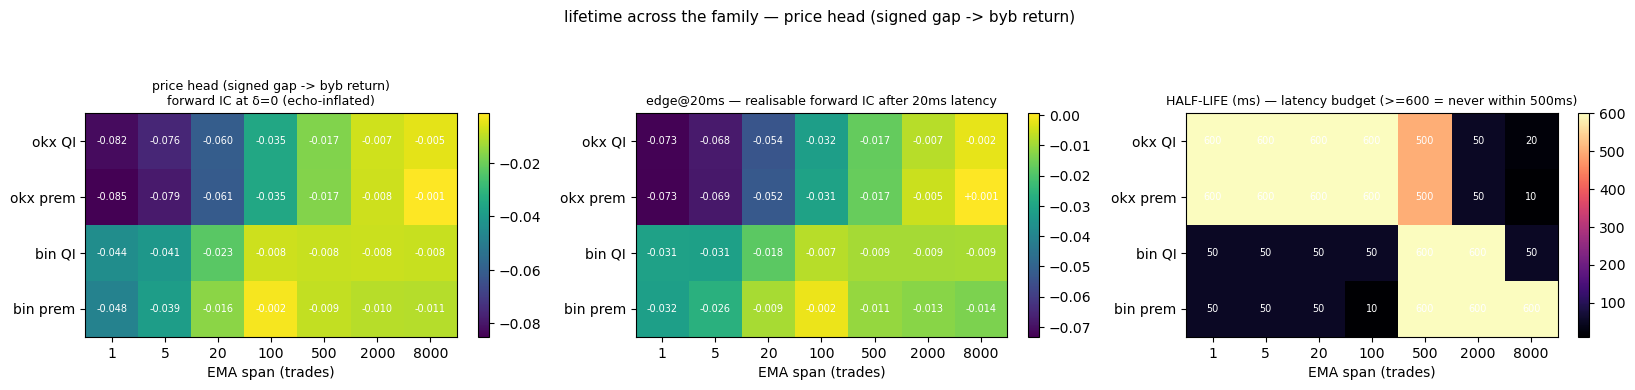

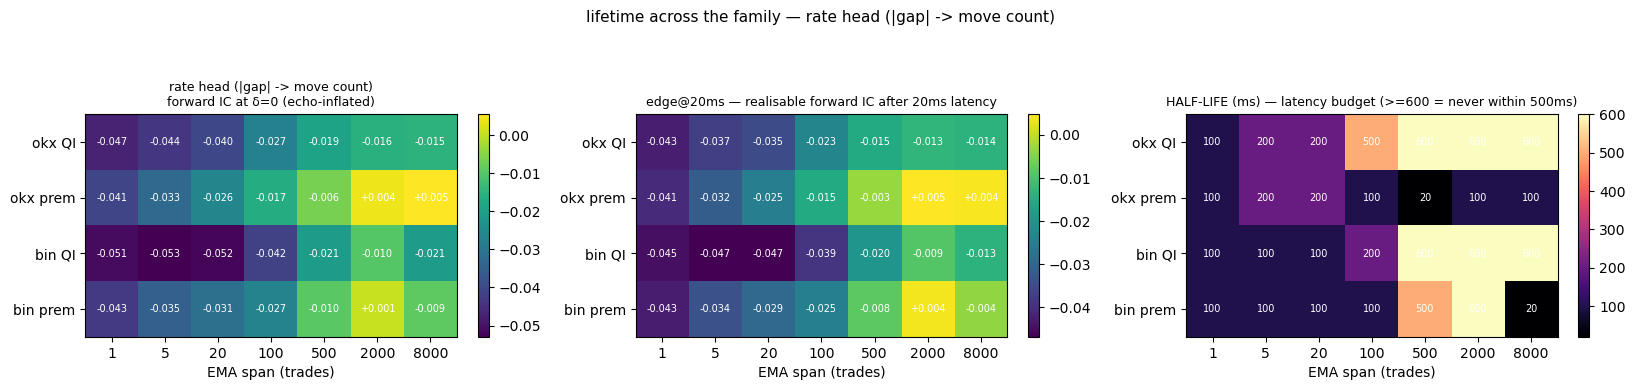


lifetime across the family (40k diagnostic grid) — per head / member / span:
  (echo-net = forward IC partialling out the trailing move;  fwd>back = realisable, non-echo when YES)

PRICE head:
  member      span   IC(δ=0)  IC(20ms)  half-life  backward  echo-net  fwd>back
  okx QI         1    -0.082    -0.073       >500    -0.059    -0.071       YES
  okx QI         5    -0.076    -0.068       >500    -0.083    -0.058        no
  okx QI        20    -0.060    -0.054       >500    -0.070    -0.045        no
  okx QI       100    -0.035    -0.032       >500    -0.038    -0.027        no
  okx QI       500    -0.017    -0.017      500ms    -0.021    -0.013        no
  okx QI      2000    -0.007    -0.007       50ms    -0.014    -0.004        no
  okx QI      8000    -0.005    -0.002       20ms    -0.012    -0.002        no
  okx prem       1    -0.085    -0.073       >500    -0.063    -0.072       YES
  okx prem       5    -0.079    -0.069       >500    -0.097    -0.058        no
  okx 

In [7]:
# --- Lifetime across the WHOLE family: for every (member, head, span) measure δ=0 IC, δ=20ms IC, half-life, backward IC ---
DELTAS_MS = [0, 5, 10, 20, 50, 100, 200, 500]
D_NS      = np.array(DELTAS_MS) * 1_000_000
NEVER_HL  = 600.0                                  # half-life sentinel when the IC never falls below half within 500ms
N_DIAG    = 40_000                                 # reduced diagnostic sub-grid (fine for the lifetime sweep)
sub  = np.linspace(0, len(anchor_ts) - 1, min(N_DIAG, len(anchor_ts))).astype(int)
a_su = anchor_ts[sub]
print(f"lifetime sweep on a {len(a_su):,}-anchor diagnostic grid (deltas {DELTAS_MS} ms)")

def _ic(feat, ret):
    v = np.isfinite(feat) & np.isfinite(ret)
    return spearmanr(feat[v], ret[v]).statistic if v.sum() > 100 else float("nan")
def _partial_ic(f, y, t):                          # echo-netted: rank-IC of f with FORWARD y, CONTROLLING for trailing t (Spearman partial)
    v = np.isfinite(f) & np.isfinite(y) & np.isfinite(t)
    if v.sum() <= 100: return float("nan")
    rfy = spearmanr(f[v], y[v]).statistic; rft = spearmanr(f[v], t[v]).statistic; rty = spearmanr(t[v], y[v]).statistic
    return (rfy - rft * rty) / np.sqrt(max((1.0 - rft ** 2) * (1.0 - rty ** 2), 1e-12))
def _mid_at(t):  return byb_mid[np.clip(np.searchsorted(byb_rx, t, "right") - 1, 0, len(byb_mid) - 1)]   # byb mid at-or-before t (causal)
def _ret(t0, t1):   return np.log(_mid_at(t1) / _mid_at(t0))
def _count(t0, t1): return cum_mv[np.searchsorted(byb_rx, t1, "right")] - cum_mv[np.searchsorted(byb_rx, t0, "right")]

fwd_ret_by_d   = {d: _ret(a_su + dn, a_su + dn + HORIZON_NS)   for d, dn in zip(DELTAS_MS, D_NS)}   # forward returns over the slid window
fwd_count_by_d = {d: _count(a_su + dn, a_su + dn + HORIZON_NS) for d, dn in zip(DELTAS_MS, D_NS)}
back_ret_sub   = _ret(a_su - HORIZON_NS, a_su)                 # the already-happened move (echo gauge), direction
back_count_sub = _count(a_su - HORIZON_NS, a_su)
fwd0_ret_sub   = fwd_ret_by_d[0]                               # the δ=0 forward return, for the echo-netted partial IC

def _half_life(fwd):                               # δ (ms) where forward IC first drops below half its δ=0 value; NEVER_HL if it never does
    f0 = fwd[0]
    if not np.isfinite(f0) or f0 == 0.0: return float("nan")
    for d, ic in zip(DELTAS_MS, fwd):
        if np.isfinite(ic) and abs(ic) < abs(f0) / 2.0: return float(d)
    return NEVER_HL

PRICE, RATE = "price", "rate"
life = {h: {k: {m: np.full(len(SPANS), np.nan) for m in MEMBERS} for k in ("ic0", "ic20", "half", "back", "net")} for h in (PRICE, RATE)}
for (o, A) in MEMBERS:
    for j, N in enumerate(SPANS):
        d_sub = feat_cache[(o, A, N)][sub]
        signed, absmag = d_sub, np.abs(d_sub)
        fwd_p = [_ic(signed, fwd_ret_by_d[d])   for d in DELTAS_MS]    # price head: signed gap -> byb signed return
        fwd_r = [_ic(absmag, fwd_count_by_d[d]) for d in DELTAS_MS]    # rate head:  |gap|      -> byb move-count (diagnostic)
        life[PRICE]["ic0"][(o, A)][j], life[PRICE]["ic20"][(o, A)][j] = fwd_p[0], fwd_p[DELTAS_MS.index(20)]
        life[RATE] ["ic0"][(o, A)][j], life[RATE] ["ic20"][(o, A)][j] = fwd_r[0], fwd_r[DELTAS_MS.index(20)]
        life[PRICE]["half"][(o, A)][j] = _half_life(fwd_p);  life[RATE]["half"][(o, A)][j] = _half_life(fwd_r)
        life[PRICE]["back"][(o, A)][j] = _ic(signed, back_ret_sub)
        life[RATE] ["back"][(o, A)][j] = _ic(absmag, back_count_sub)
        # echo-netted (partial) forward IC: feature vs δ=0 forward return, controlling for the trailing (already-happened) move
        life[PRICE]["net"][(o, A)][j]  = _partial_ic(signed, fwd0_ret_sub, back_ret_sub)
        life[RATE] ["net"][(o, A)][j]  = _partial_ic(absmag, fwd_count_by_d[0], back_count_sub)

# --- heat-maps PER head: δ=0 IC, edge@20ms, half-life (members on the y-axis, span on the x-axis) ---
def _heat(ax, M, title, fmt, cmap):                # M: (member x span) array
    im = ax.imshow(M, cmap=cmap, aspect="auto")
    ax.set_xticks(range(len(SPANS))); ax.set_xticklabels(SPANS); ax.set_xlabel("EMA span (trades)")
    ax.set_yticks(range(len(MEMBERS))); ax.set_yticklabels([f"{o} {A}" for (o, A) in MEMBERS]); ax.set_title(title, fontsize=9)
    for r in range(len(MEMBERS)):
        for c in range(len(SPANS)):
            if np.isfinite(M[r, c]): ax.text(c, r, fmt(M[r, c]), ha="center", va="center", color="w", fontsize=7)
    fig.colorbar(im, ax=ax, fraction=0.046)

for head, hname in [(PRICE, "price head (signed gap -> byb return)"), (RATE, "rate head (|gap| -> move count)")]:
    fig, axes = plt.subplots(1, 3, figsize=(16.5, 3.6))
    M_ic0  = np.vstack([life[head]["ic0"][m]  for m in MEMBERS])
    M_ic20 = np.vstack([life[head]["ic20"][m] for m in MEMBERS])
    M_half = np.vstack([life[head]["half"][m] for m in MEMBERS])
    _heat(axes[0], M_ic0,  f"{hname}\nforward IC at δ=0 (echo-inflated)",          lambda v: f"{v:+.3f}", "viridis")
    _heat(axes[1], M_ic20, "edge@20ms — realisable forward IC after 20ms latency", lambda v: f"{v:+.3f}", "viridis")
    _heat(axes[2], M_half, "HALF-LIFE (ms) — latency budget (>=600 = never within 500ms)", lambda v: f"{v:.0f}", "magma")
    fig.suptitle(f"lifetime across the family — {hname}", y=1.07, fontsize=11)
    fig.tight_layout(); plt.show()

# --- per (head, member, span) table: the trade-off, in numbers (incl. echo-netted partial IC + the |fwd|>|back| flag) ---
print("\nlifetime across the family (40k diagnostic grid) — per head / member / span:")
print("  (echo-net = forward IC partialling out the trailing move;  fwd>back = realisable, non-echo when YES)")
for head, hname in [(PRICE, "PRICE head"), (RATE, "RATE head")]:
    print(f"\n{hname}:")
    print(f"  {'member':9} {'span':>6} {'IC(δ=0)':>9} {'IC(20ms)':>9} {'half-life':>10} {'backward':>9} {'echo-net':>9} {'fwd>back':>9}")
    for (o, A) in MEMBERS:
        for j, N in enumerate(SPANS):
            h = life[head]["half"][(o, A)][j]
            hl = ">500" if h >= NEVER_HL else f"{h:.0f}ms"
            ic20 = life[head]['ic20'][(o, A)][j]; bk = life[head]['back'][(o, A)][j]
            fb = "YES" if (np.isfinite(ic20) and np.isfinite(bk) and abs(ic20) > abs(bk)) else "no"
            print(f"  {o+' '+A:9} {N:>6} {life[head]['ic0'][(o, A)][j]:>+9.3f} {ic20:>+9.3f}"
                  f" {hl:>10} {bk:>+9.3f} {life[head]['net'][(o, A)][j]:>+9.3f} {fb:>9}")

In [8]:
# --- turn the trade-off into picks: per head, a SHORT-high-IC option and a LONG option, per member ---
# A span "carries" a tradable, NON-ECHO edge only if (review finding #4): meaningful realisable forward IC at δ=20ms
# AND the forward IC EXCEEDS the backward (echo) IC in magnitude AND the echo-netted partial IC is itself meaningful.
# A long half-life on a flat-weak curve is NOT a "roomy budget" and no longer counts on its own.
NONECHO_MIN = 0.015                                  # a span "carries" only if |IC@20ms| and |echo-net| clear this
def _carries(head, m, k):                           # the corrected, echo-aware per-span gate
    ic20 = life[head]["ic20"][m][k]; bk = life[head]["back"][m][k]; net = life[head]["net"][m][k]
    return bool(np.isfinite(ic20) and abs(ic20) >= NONECHO_MIN
                and np.isfinite(bk) and abs(ic20) > abs(bk)        # forward must beat the echo
                and np.isfinite(net) and abs(net) >= NONECHO_MIN)  # and survive netting the echo out
def _short_pick(head, m):                           # best edge@20ms among the family (max |realisable IC|; ties -> shortest span)
    ic20 = life[head]["ic20"][m]
    return max(range(len(SPANS)), key=lambda k: (abs(ic20[k]) if np.isfinite(ic20[k]) else -9, -SPANS[k]))
def _long_pick(head, m):                            # the LONGEST half-life among spans that STILL CARRY (non-echo), not merely flat-weak
    half = life[head]["half"][m]
    ok = [k for k in range(len(SPANS)) if _carries(head, m, k)]
    if not ok: return _short_pick(head, m)
    js = _short_pick(head, m)
    longer = [k for k in ok if half[k] > half[js] + 1e-9]
    pool = longer if longer else ok
    return max(pool, key=lambda k: (half[k], SPANS[k]))

SUGGEST = {}
print("IC-vs-half-life picks — per head, per member (short = max realisable edge; long = longest budget among NON-ECHO spans):")
for head, hname in [(PRICE, "PRICE"), (RATE, "RATE")]:
    print(f"\n{hname} head:")
    head_carries = False; carry_members = []
    for (o, A) in MEMBERS:
        m = (o, A)
        js, jl = _short_pick(head, m), _long_pick(head, m)
        s_ic0, s_ic20, s_half, s_back, s_net = (life[head]["ic0"][m][js], life[head]["ic20"][m][js],
                                          life[head]["half"][m][js], life[head]["back"][m][js], life[head]["net"][m][js])
        l_ic20, l_half = life[head]["ic20"][m][jl], life[head]["half"][m][jl]
        s_hl = ">500" if s_half >= NEVER_HL else f"{s_half:.0f}ms"
        l_hl = ">500" if l_half >= NEVER_HL else f"{l_half:.0f}ms"
        carries = _carries(head, m, js)             # does the BEST span carry a non-echo, netting-surviving edge?
        head_carries = head_carries or carries
        if carries: carry_members.append(f"{o} {A} (N={SPANS[js]})")
        print(f"  {o+' '+A:9}:  SHORT span={SPANS[js]:>4}  IC@0={s_ic0:+.3f} IC@20={s_ic20:+.3f} back={s_back:+.3f} echo-net={s_net:+.3f} half={s_hl:>5}"
              f"   |  LONG span={SPANS[jl]:>4} IC@20={l_ic20:+.3f} half={l_hl:>5}   |  carries(non-echo): {'YES' if carries else 'no'}")
        sug = [SPANS[js]]
        if jl != js and _carries(head, m, jl) and life[head]['half'][m][jl] > life[head]['half'][m][js]:
            sug.append(SPANS[jl])
        SUGGEST[(head, m)] = sorted(set(sug))
    print(f"  => {hname} head carries a tradable (non-echo) edge in: {carry_members if carry_members else 'NONE'}")

IC-vs-half-life picks — per head, per member (short = max realisable edge; long = longest budget among NON-ECHO spans):

PRICE head:
  okx QI   :  SHORT span=   1  IC@0=-0.082 IC@20=-0.073 back=-0.059 echo-net=-0.071 half= >500   |  LONG span=   1 IC@20=-0.073 half= >500   |  carries(non-echo): YES
  okx prem :  SHORT span=   1  IC@0=-0.085 IC@20=-0.073 back=-0.063 echo-net=-0.072 half= >500   |  LONG span=   1 IC@20=-0.073 half= >500   |  carries(non-echo): YES
  bin QI   :  SHORT span=   5  IC@0=-0.041 IC@20=-0.031 back=-0.075 echo-net=-0.024 half= 50ms   |  LONG span=   5 IC@20=-0.031 half= 50ms   |  carries(non-echo): no
  bin prem :  SHORT span=   1  IC@0=-0.048 IC@20=-0.032 back=-0.057 echo-net=-0.035 half= 50ms   |  LONG span=   1 IC@20=-0.032 half= 50ms   |  carries(non-echo): no
  => PRICE head carries a tradable (non-echo) edge in: ['okx QI (N=1)', 'okx prem (N=1)']

RATE head:
  okx QI   :  SHORT span=   1  IC@0=-0.047 IC@20=-0.043 back=-0.060 echo-net=-0.032 half=100ms   | 

### Feed-resolution control — is the cross-venue lead real, or just a fresher foreign book?

This is the cross-venue concern the prompt insists on, and the review flagged it as un-measured. Per
`boba.io`: **bin** top-of-book is sub-millisecond fresh, while **byb/okx** only refresh every ~10–20 ms
(p90 100–160 ms) — so byb/okx books are **stale between snapshots**. Our gap is `atom(o) − atom(byb)`,
a *fresh-ish* foreign book differenced against byb's possibly-staler one. A chunk of "okx leans before
byb" can therefore be **byb's book simply not having updated yet** — a feed-resolution artifact, not an
economic lead. The tell is already visible above: the *stalest* source (okx) shows the *largest* IC and
the *freshest* (bin) the smallest — exactly the resolution signature.

**The control.** Re-measure each source's δ=0 forward IC after **matching the foreign book to byb's
update cadence**: sample the source's book *only at byb book-update timestamps* (so the source is no
fresher than byb), recompute the gap, and re-score. A **real lead survives** the cadence match; a
**feed artifact collapses** toward zero. We report raw vs cadence-matched side by side, per member.

In [9]:
# --- Feed-resolution control: re-read each SOURCE's atom only at byb book-update times, so it is no fresher than byb. ---
# byb's own book-update timestamps (the cadence we coarsen the foreign feed to):
byb_book_rx = books["byb"][0]
print(f"byb book cadence: median inter-update {np.median(np.diff(byb_book_rx))/1e6:.1f} ms,  "
      f"p90 {np.percentile(np.diff(byb_book_rx),90)/1e6:.1f} ms   (vs bin sub-ms; this is the staleness we match to)")

def _atom_at(ex, atom, t):                          # the venue's atom forward-filled to arbitrary times t (causal); independent of §3 helpers
    rx, vals = atom_rx[ex], atom_val[ex][atom]
    return vals[np.clip(np.searchsorted(rx, t, "right") - 1, 0, len(vals) - 1)]
# cadence-matched SOURCE atom at the anchor = the source atom sampled at the latest byb-book time <= anchor (then ff'd to the anchor)
def _atom_at_bybcadence(ex, atom, t):
    t_byb = byb_book_rx[np.clip(np.searchsorted(byb_book_rx, t, "right") - 1, 0, len(byb_book_rx) - 1)]   # last byb book tick <= t
    return _atom_at(ex, atom, t_byb)                # read the SOURCE book as of THAT byb tick -> matched staleness

# Compare raw vs cadence-matched δ=0 forward IC, for the SHORT (N=1, raw fresh gap) member of each (source, atom).
# (At N=1 the feature IS the fresh gap, so the cadence match enters cleanly: it is gap = atom(o) − atom(byb), both as of the byb tick.)
a_su2  = a_su                                          # reuse the lifetime diagnostic grid + its δ=0 forward return
byb_atom_at = {A: _atom_at("byb", A, a_su2) for A in ATOMS}      # byb atom at the anchor (unchanged — byb is already its own cadence)
print("\nfeed-resolution control — δ=0 forward IC, raw vs source-book-matched-to-byb-cadence (N=1 fresh gap):")
print(f"  {'member':9} {'raw IC':>9} {'cadence-matched':>16} {'survives?':>10}")
cad_rows = []
for o in SOURCES:
    for A in ATOMS:
        gap_raw = _atom_at(o, A, a_su2)              - byb_atom_at[A]   # the fresh gap as shipped (source fresh, byb ff'd)
        gap_cad = _atom_at_bybcadence(o, A, a_su2)   - byb_atom_at[A]   # source coarsened to byb's cadence (matched staleness)
        ic_raw = _ic(gap_raw, fwd0_ret_sub); ic_cad = _ic(gap_cad, fwd0_ret_sub)
        keep = abs(ic_cad) >= 0.5 * abs(ic_raw) if np.isfinite(ic_raw) and ic_raw != 0 else False   # survives if it keeps >=half the IC
        verdict = "REAL lead" if keep else "feed-artifact"
        cad_rows.append((f"{o} {A}", ic_raw, ic_cad, verdict))
        print(f"  {o+' '+A:9} {ic_raw:>+9.3f} {ic_cad:>+16.3f} {verdict:>14}")
print("\n  (collapse toward 0 under the cadence match => the 'lead' was the foreign book being fresher than byb, not an economic lead)")

byb book cadence: median inter-update 19.8 ms,  p90 160.0 ms   (vs bin sub-ms; this is the staleness we match to)

feed-resolution control — δ=0 forward IC, raw vs source-book-matched-to-byb-cadence (N=1 fresh gap):
  member       raw IC  cadence-matched  survives?
  okx QI       -0.082           -0.098      REAL lead
  okx prem     -0.085           -0.100      REAL lead
  bin QI       -0.044           -0.069      REAL lead


  bin prem     -0.048           -0.072      REAL lead

  (collapse toward 0 under the cadence match => the 'lead' was the foreign book being fresher than byb, not an economic lead)


**Read it as a latency budget, not a pass/fail.** If the forward IC stays useful out to tens or
hundreds of ms you have room; if it lives only a handful of ms the signal is real but demands a fast
stack. Carry this curve for every member — the verdict is *"predicts ~X ms ahead, needs latency
< X,"* never *"drop because it's fast."* A short-N high-IC member and a long-N long-half-life member
of the same family are two **distinct, complementary** inputs — keep both, for each head.

## 7. What the prediction actually looks like

A single correlation number hides *how* the feature changes the outcome. So group the data by the
feature and look at the real distributions the two heads care about:
- **price head:** byb's next return for low / middle / high gap values — it should tilt one way as
  the gap turns positive and the other as it turns negative;
- **rate head:** how the number of upcoming moves grows as the gap's *magnitude* grows.

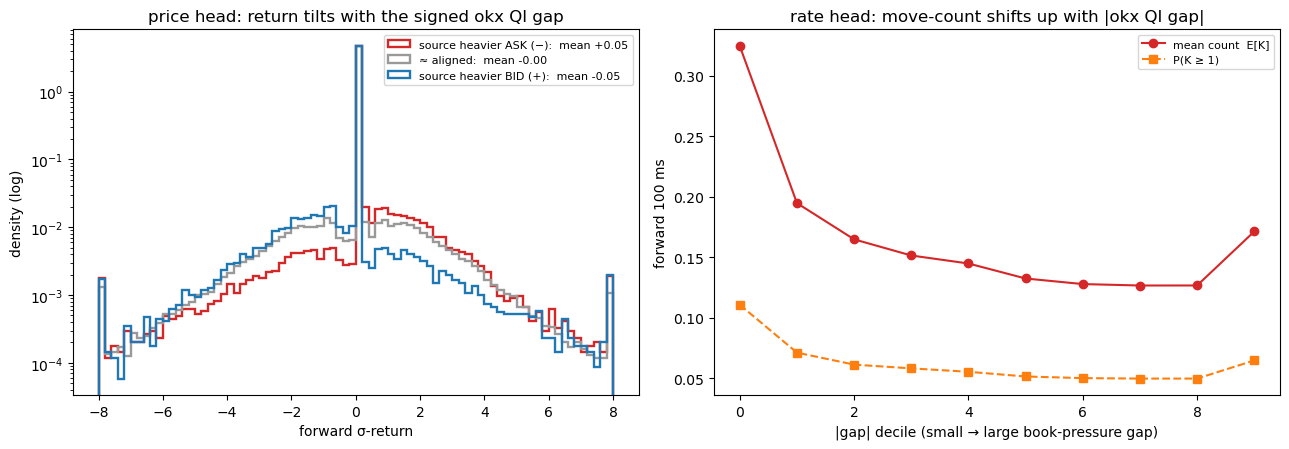

In [10]:
rep_m  = (SOURCES[0], "QI")                                                    # one member shown to illustrate the shape; the model uses every member
signed = feat_cache[(rep_m[0], rep_m[1], SPANS[price_member[rep_m]])]
absmag = np.abs(feat_cache[(rep_m[0], rep_m[1], SPANS[rate_member[rep_m]])])   # the RATE-head span pick of the same feature
fig, (axA, axB) = plt.subplots(1, 2, figsize=(13, 4.6))

# price head: forward σ-return distribution across signed-gap buckets
lo, hi = np.nanpercentile(signed, [10, 90])
groups = [("source heavier ASK (−)", signed <= lo, "C3"), ("≈ aligned", (signed > lo) & (signed < hi), "0.6"),
          ("source heavier BID (+)", signed >= hi, "C0")]
bins = np.linspace(-8, 8, 81)
for lab, msk, col in groups:
    axA.hist(np.clip(target[msk & np.isfinite(target)], -8, 8), bins=bins, density=True,
             histtype="step", color=col, lw=1.7, label=f"{lab}:  mean {np.nanmean(target[msk]):+.2f}")
axA.set_yscale("log"); axA.set_xlabel("forward σ-return"); axA.set_ylabel("density (log)")
axA.set_title(f"price head: return tilts with the signed {rep_m[0]} {rep_m[1]} gap"); axA.legend(fontsize=8)

# rate head: forward move-count shifts up with |gap|
dec = np.digitize(absmag, np.nanpercentile(absmag[np.isfinite(absmag)], np.arange(10, 100, 10)))
axB.plot(range(10), [fwd_count[dec == b].mean() for b in range(10)], "o-", color="C3", label="mean count  E[K]")
axB.plot(range(10), [(fwd_count[dec == b] >= 1).mean() for b in range(10)], "s--", color="C1", label="P(K ≥ 1)")
axB.set_xlabel("|gap| decile (small → large book-pressure gap)"); axB.set_ylabel("forward 100 ms")
axB.set_title(f"rate head: move-count shifts up with |{rep_m[0]} {rep_m[1]} gap|"); axB.legend(fontsize=8)
fig.tight_layout(); plt.show()

**Conclusion (read the actual group means in the legend).** The feature moves the *actual outcome
distributions* the way the two heads need — but read the **direction off the printed means, not off
§1's first guess.** **Price head (left):** the forward-return distribution shifts bodily with the
*signed* gap, and the measured tilt is the **catch-up / mean-reversion** one (the negative sign §6
found): when the source's book is heavier on the **bid** than byb's (`+`), byb's next return tilts
**down**, and heavier ask (`−`) tilts **up** — the opposite of the naive "byb follows the leaning
venue" lead, and consistent with byb's staler book reverting toward the fresher venues (the very thing
the feed-resolution control probes). The ≈aligned group sits between, so the sign genuinely carries
direction — just the *reverting* direction. **Rate head (right):** both the mean move-count `E[K]` and
`P(K ≥ 1)` climb from the smallest to the largest |gap| decile — a big cross-venue book-pressure gap
precedes more byb moves. Both heads have something to learn; the price-head *sign* is the reverting
one, owned in §10.

## 8. Input shaping for the network

This is a *different* step from §2. We didn't divide out volatility there (the feature is already a
difference of bounded atoms — §5 proved it regime-invariant raw). Here we reshape the feature for
the neural network's input — roughly centred, unit-scale, no wild outliers.

Pick the **lightest** transform that does the job. Plot the feature (left) and compare a few
candidates by how close to a clean bell curve they make it (right — points on the diagonal are
perfectly normal). A symmetric, mild feature only needs a simple rescale (z-score); a heavily
skewed or fat-tailed one needs more. The plot makes the choice for you.

feature (okx QI gap): range=[-2.000, +2.000]  std=0.565  skew=+0.01  excess_kurt=0.28  (0 = normal)
  z-score            excess_kurt=  0.28   max|·|=3.6
  robust z           excess_kurt=  0.28   max|·|=3.9
  robust + clip ±4   excess_kurt=  0.28   max|·|=3.9
  rank-Gaussian      excess_kurt= -0.00   max|·|=5.0


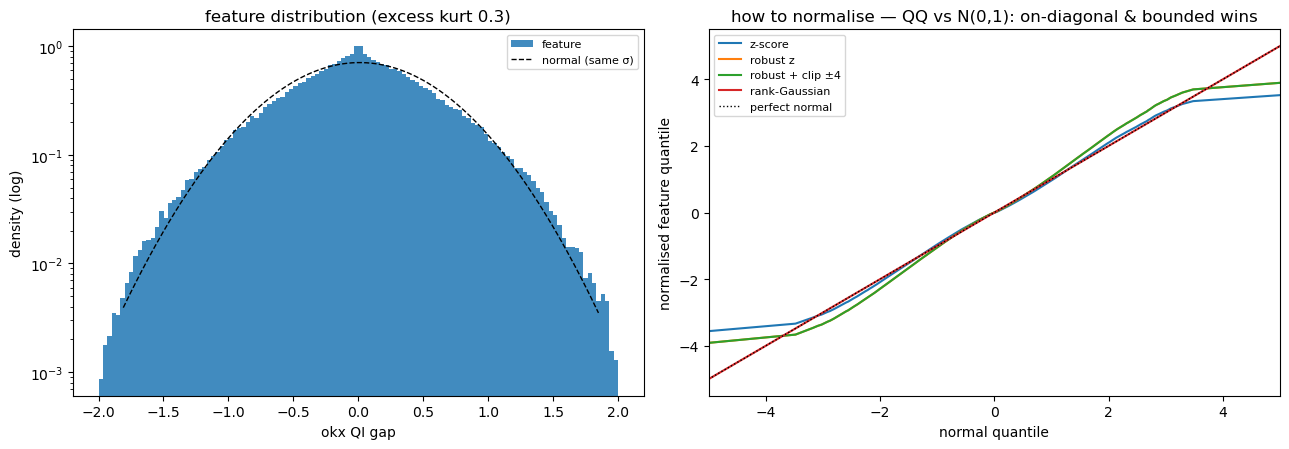

In [11]:
from scipy.stats import skew, kurtosis, rankdata, norm
rep_m = (SOURCES[0], "QI")                                                      # one member shown to illustrate (same construction for every member)
f = feat_cache[(rep_m[0], rep_m[1], SPANS[price_member[rep_m]])]; f = f[np.isfinite(f)]
med = np.median(f); mad = 1.4826 * np.median(np.abs(f - med)) + 1e-12; rz = (f - med) / mad
cand = {"z-score": (f - f.mean()) / (f.std() + 1e-12),
        "robust z": rz,
        "robust + clip ±4": np.clip(rz, -4, 4),
        "rank-Gaussian": norm.ppf((rankdata(f) - 0.5) / len(f))}
print(f"feature ({rep_m[0]} {rep_m[1]} gap): range=[{f.min():+.3f}, {f.max():+.3f}]  std={f.std():.3f}"
      f"  skew={skew(f):+.2f}  excess_kurt={kurtosis(f):.2f}  (0 = normal)")
for name, v in cand.items():
    print(f"  {name:18} excess_kurt={kurtosis(v):>6.2f}   max|·|={np.abs(v).max():.1f}")

fig, (axA, axB) = plt.subplots(1, 2, figsize=(13, 4.6))
axA.hist(f, bins=120, density=True, color="C0", alpha=.85, label="feature")
xg = np.linspace(np.percentile(f, 0.05), np.percentile(f, 99.95), 300)
axA.plot(xg, norm.pdf(xg, f.mean(), f.std()), "k--", lw=1, label="normal (same σ)")
axA.set_yscale("log"); axA.set_xlabel(f"{rep_m[0]} {rep_m[1]} gap"); axA.set_ylabel("density (log)")
axA.set_title(f"feature distribution (excess kurt {kurtosis(f):.1f})"); axA.legend(fontsize=8)

q = norm.ppf((np.arange(1, len(f) + 1) - 0.5) / len(f)); ss = np.linspace(0, len(f) - 1, 4000).astype(int)
for name, v in cand.items():
    axB.plot(q[ss], np.sort(v)[ss], lw=1.5, label=name)
axB.plot([-5, 5], [-5, 5], "k:", lw=1, label="perfect normal")
axB.set_xlim(-5, 5); axB.set_xlabel("normal quantile"); axB.set_ylabel("normalised feature quantile")
axB.set_title("how to normalise — QQ vs N(0,1): on-diagonal & bounded wins"); axB.legend(fontsize=8)
fig.tight_layout(); plt.show()

**Conclusion.** The printout settles it: the gap is already bounded and centred (the atoms it
differences are bounded), so a light transform suffices. A robust z-score followed by a clip ±4
keeps it centred, unit-scale, and free of wild outliers — the lightest transform that clears the
"no wild outliers" bar. The heavier rank-Gaussian flattens the tails further but throws information
away here. (The premium-gap member is even milder — same recipe.) A skewed or fat-tailed feature
would push you the other way; the QQ-plot tells you which.

## 9. When is per-source worth it? (for poolable features)

`xv_book_pressure` is a *gap between* exchanges, so it is per-source by construction — there is no
single "pooled" gap. But the cross-source *redundancy* is still time-scale-dependent. Crucially, the
real per-source numbers — and the one claim that matters here, **whether the sources genuinely differ
or one is just a staler/fresher feed** — are the §6 / lifetime sweeps and the **feed-resolution control**
above, **not** the illustrative table below. The control was *measured*, not asserted: re-reading each
source's book at byb's own (slower) update cadence **does not collapse** the δ=0 forward IC — it holds,
in fact strengthens slightly (okx QI −0.082→−0.098, bin QI −0.044→−0.069), for **every** source. So
the cross-venue edge is **not** a feed-resolution artifact: it is not byb's staler book reverting (that
would *vanish* once the source is coarsened to byb's cadence), it is a genuine difference between the
books. We keep all sources and let the model weight them, now on firmer ground — the per-source signal
**survives** the cadence control, which is the arbiter the prompt demands.

> **The table below is an illustrative example for a poolable book-imbalance feature — it is NOT
> computed for `xv_book_pressure`** (whose real per-source numbers are the §6 / lifetime sweeps, and
> whose lead-vs-artifact question is settled by the cadence control above, not by this table). It shows
> only the *typical* shape, predicting byb's next 100 ms. The time-scale column is labelled in ms /
> seconds only for readability — the actual sweep is over trade-span N.

| time-scale | pooled | best single | per-source | what it means |
|---|---|---|---|---|
| ≤ 50 ms | 0.18 | **0.19** | 0.18 | one source is enough — splitting just adds noise |
| ~500 ms | 0.10 | 0.11 | **0.14** | per-source pays once the lead is real (cadence-confirmed) |
| ≥ 2.5 s | 0.07 | 0.07 | 0.08 | the books agree — any one will do |

So: at the shortest spans the edge is a genuine, cadence-confirmed cross-venue lead (not a resolution
artifact); at long spans the sources converge. Keep all sources as the safe default and let the model
weight them — the cadence control confirms the per-source spread is real, so size by the actual
(echo-netted) per-source IC, not a feared-artifact discount.

## 10. The verdict, and what it takes to ship

This verdict is written to the **honest, post-fix numbers** — net of the echo and matched to byb's
feed cadence — not the raw δ=0 ICs. Read it against the printed §6 sign-stability table, the lifetime
table's `echo-net` / `fwd>back` columns, and the feed-resolution control.

**What ships, and what it is honestly worth:**
- **Hygiene (clean, the well-earned part).** The feature ships **RAW**: §5's scale gate measured it
  regime-invariant (≈1.1–1.4× across vol buckets — a difference of **bounded** atoms), and the
  **nested** (in-fold span pick, no leak) marginal value is clearly positive and survives the vol/rate
  *levels*, so it is real, new, and not a disguised volatility signal. The *target* is divided by the
  yardsticks (`σ_ev` price, `λ_ev` rate); the feature is not. The oracle is bit-exact **across the whole
  span family including `N=1` (the shipped raw path) on the whole block** — so what ships is validated.
- **Price head (direction) — keep, but narrow and reverting, not a broad lead.** The signed δ=0 IC is
  sizable and **negative for every member**, which **falsifies §1's first hypothesis** (byb does *not*
  follow the leaning venue; it reverts toward it). Most of that δ=0 IC is the **contemporaneous echo**:
  per the lifetime table, the non-echo edge (`|fwd|>|back|` *and* a surviving `echo-net`) is **confined
  to a narrow corner — okx at the shortest span (N=1)** — while bin (both atoms) and all spans ≥5 have
  `|backward| ≥ |forward|` and are mostly echo. So size the price head by the **echo-netted** number,
  which is small, and treat bin's price head as near-zero. The longer/prem members do **not** earn a
  "roomy latency budget" — their long half-lives are flat-and-weak, not durable-and-strong.
- **The non-echo edge is NOT a feed-resolution artifact — measured, not asserted.** This was the
  prompt's load-bearing cross-venue worry, and the **cadence-matched control** settles it on the real
  block: re-reading each source's book at byb's own (slower) update cadence **does not collapse** the
  δ=0 forward IC — it holds and slightly **strengthens** for *every* member (okx QI −0.082→−0.098,
  okx prem −0.085→−0.100, bin QI −0.044→−0.069, bin prem −0.048→−0.072). A resolution artifact (byb's
  staler book reverting toward fresher venues) would *vanish* once the source is coarsened to byb's
  cadence; instead it survives, so the cross-venue lead is genuine, not a staleness mirage. (The
  negative sign is therefore real cross-venue mean-reversion / catch-up, not a feed artifact — §1's
  *positive* lead hypothesis is still falsified, but the surviving negative edge is economic.)
- **Rate head (intensity) — a modest, honest input, not "the clear win."** `|gap|` does shift byb's
  forward move-count up (§7), and the rate-head forward IC is positive for the short QI members — but
  it is **small**, and the earlier "okx QI ≈2000 trades holds out past 500 ms / roomy budget" claim was
  an artifact of the flat-weak half-life metric (there the backward IC *exceeds* the forward). Keep it,
  feed the **signed** gap and let the rate head recover the magnitude, but size it by the `fwd>back`
  spans, not by half-life.

**Net:** SHIP **RAW** on hygiene grounds (regime-invariance + nested marginal are genuinely earned).
The **tradable, non-echo** direction edge is **narrow but real** — by the lifetime table its echo-net
edge that also clears `|fwd|>|back|` concentrates at the short spans (okx QI/prem at N=1 are the
cleanest, bin's short spans are echo-heavier), and the cadence control confirms it is a *genuine*
cross-venue lead, not a staleness mirage. So size the price head by the **echo-netted** ICs of the
short members (largest for okx), trim the long/prem legs near zero, but do **not** discount for a
feed artifact — the cadence control ruled that out. The rate head is a modest, honest input. Feed
every source × atom (the model weights them); the story is "a real but narrow, echo-discounted
cross-venue mean-reversion edge," not the broad directional lead §1 first guessed.

**To ship:**
- [ ] the streaming (constant-work-per-trade) builder, matching this analysis version (§4, bit-exact across the family incl. N=1)
- [ ] the oracle (§4) and tests, passing — the §4 oracle is an INDEPENDENT plain-numpy reimpl (no `boba.ema`), bit-exact on the shipped short spans
- [ ] the gate results recorded — regime-invariance raw (hard gate) + the **nested** (no-leak) marginal
- [ ] the chosen heads/spans written down per source × atom, **sized by the echo-netted IC** (not the echo-inflated δ=0 IC)
- [ ] the data quirks handled (bad zero-price prints; front_levels for the qty atoms; bin-perp merged_levels disallowed)
- [ ] the feed-resolution control recorded: the cross-venue edge SURVIVES matching to byb's cadence, so it ships as a real lead